In [1]:
import glob
import os
import time
import h5py
import matplotlib.pylab as plt
import numpy as np
import numpy.ma as ma
from matplotlib.offsetbox import AnchoredText
from matplotlib.pylab import colorbar 
from skrf import Network, Frequency
import math
import psutil
import matplotlib.cm as cm

# imported from "DNS_Timing_Publication_Figures.ipynb"
from matplotlib.pyplot import *
from scipy.special import erf
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
#from matplotlib import cm
import matplotlib.colors

style = 'fast'
tick_dir = 'in'
plt.style.use(style)
plt.rcParams['xtick.direction'] = tick_dir
plt.rcParams['ytick.direction'] = tick_dir
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"})

###################################################################################
# Analog chain labels
###################################################################################

#pathtoacfile = "/home/observer/tone_jupyter/anachainz.csv"
#ac = np.genfromtxt(pathtoacfile, delimiter=",", names=True,
#                   dtype=(int, int, 'U5', 'U5', int, 'U2', int))
#inputs = ac['feed']

def get_beam_fwhm(d=6.0, nu=600):
    fwhm = constants.c/(nu*1e6)/d   # lambda/D
    return np.rad2deg(fwhm * 1.22)

def gaussian(x, a, mean, sigma):
    val = a * np.exp(-(x - mean)**2 / sigma**2)
    return val

def scale_zero_one(x):
    return (x - x.min())/(x.max() - x.min())

def seconds_to_degrees(seconds, declination=22.0145):
    """
    convert seconds to degrees of sky motion at a latitude default TONE latitude default for cra
    """
    return seconds * np.cos(np.deg2rad(declination)) / 240

def read_corr_mode_h5(file_path, f_start=None, f_stop=None):
    """
    Reading all hdf5 files
    """
    class correlator_data:
        def __init__(self, vis, time, sat, index_map):
            self.vis = vis
            self.time = time
            self.sat = sat
            self.freq = index_map["freq"][:]
            self.prod = index_map['prod'][:]
    files = glob.glob(file_path + "*[!.lock]")
    files.sort()
    
    #grab different sets of files.  
    if f_start is not None:
        if f_stop is not None:
            files = files[f_start:f_stop]
        else:
            files = files[f_start:]
    if f_start is None:
        if f_stop is not None:
            files = files[:f_stop]

    try:
        t = 0
        for x in files:
            print(f"Reading File: {x}")
            f = h5py.File(x, "r")
            index_map = f['index_map']
            if(t == 0):
                vis = f['vis'][:]
                time = index_map['time'][:]
                sat = f['sat'][:]
                print("Appended vis data and time stream from %s" % (x))
                t = t + 1
            else:
                time = np.append(time, index_map['time'][:])
                vis = np.append(vis, f['vis'][:], axis=0)
                sat = np.append(sat, f['sat'][:], axis=0)
                print("Appended vis data and time stream from %s" % (x))
        
        return correlator_data(
            vis,
            time,
            sat,
            index_map
        )
    finally:
        print("Done!!!!!!!")

def get_mag_phase(power0):
    """
    # return magnitude and phase in degrees of correlations
    """
    return np.absolute(power0), np.rad2deg(np.angle(power0))

def plot_waterfall_corr_data(data, corr_indices):
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for i,auto in enumerate(corr_indices):
        plt.subplot(dim1, dim2, i + 1)
        wfall = data[:, :, auto] # auto -> corr index 
        plt.imshow(wfall, vmin = np.nanpercentile(wfall,5), vmax =np.nanpercentile(wfall,95), aspect='auto')
        plt.xlabel("freq index")
        plt.ylabel("time index")
        plt.title(f"corr {corr_data.prod[auto]}")
    plt.tight_layout()
    
def plot_freq_channel_corr_data(pow_mag, freq_index, freq, corr_indices):
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for index, corr_index in enumerate(corr_indices):
            plt.subplot(dim1, dim2, index + 1)
            plt.title(f"Corr: {corr_data.prod[corr_index]}")
            #plt.plot(pow_mag[:, freq_index, corr_index])
            plt.plot(pow_mag[:, :, corr_index])

    plt.suptitle(f"Frequency {freq} MHz")
    plt.tight_layout()


In [ ]:
#reading digital gains (.h5 file)
f = h5py.File("/Users/kalyanibhopi94/Documents/iceboard_data/digital_gains/20250319T171034Z_WVUc52_digitalgain/00000057.h5","r")

#plotting digital gains 
print(list(f.attrs))
print(f.attrs['acquisition_name'])
print(f.attrs['archive_version'])
print(f.attrs['collection_server'])
print(f.attrs['git_version_tag'])
print(f.attrs['instrument_name'])
print(f.attrs['notes'])
print(f.attrs['system_user'])
print(f.attrs['type'])
print(f.attrs['version'])

print(list(f.items()))
print((f['compute_time']))
print((f['index_map']))
print((f['gain_coeff']))
print((f['gain_exp'])) 

inputs = (f['index_map']['input'][:])
frqs = f['index_map']['freq'][:]
gaincoeff = f['gain_coeff'][()]
gainexp = f['gain_exp'][()]
gain = gaincoeff.real*np.exp2(gainexp)

plt.figure(figsize=[16,18])
print(f"Calculating digital gains of the channels...")
i = 0
for i in np.arange(0,4,1):  
    plt.subplot(8,2,i+1)
    #Digital gain of every channel
    plt.scatter(frqs['centre'], gain[0][:,i]) # i referes to input channel (total 16 ch on iceboard); 
    #plt.title( " %s and gain_exp = %s and rms %s for rms i/p %s" %(inputs[i], gainexp[:,i], rms[i][2], rms[i][0][2]))
    plt.title( " %s " %(inputs[i]))
plt.tight_layout()


In [ ]:
def beam_amp_recovery(freq_arr):
    """Function to plot beam amplitude recovery (%):
    
    Parameters
    ----------
    
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels
    """

    colorsarr=cm.inferno(np.linspace(0,1,1024))
    fig = plt.figure(figsize=[14,12])
    for index,f_ind in enumerate(freq_arr):
        
        #Loading stats from saved files:
        avgs=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_fbin{f_ind}.npz")
        avgs_off=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_off_fbin{f_ind}.npz")
        stds=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/stds_fbin{f_ind}.npz")
        var=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_fbin{f_ind}.npz")
        var_off=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_off_fbin{f_ind}.npz")


        """stats from saved files -- N 65536 (steps of 5 degrees) (range -50 t0 130)
        autos and crosses means, std dev and variances lists -- correlator data 
        
        Parameters
        ----------

        autos_0x0 -- <VV*>t,ON
        autos_0x0_off -- <VV*>t,OFF
        crosses_0x1 -- <VtVref*>ON
        autos_1x1 -- <VV*>ref,ON 
        autos_1x1_off -- <VV*>ref,OFF (which is 0 in this case) 
        """
        
        autos_0x0 = [avgs['avgs50n'][0], avgs['avgs45n'][0], avgs['avgs40n'][0], avgs['avgs35n'][0], avgs['avgs30n'][0], avgs['avgs25n'][0], avgs['avgs20n'][0], avgs['avgs15n'][0], avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0], avgs['avgs15p'][0], avgs['avgs20p'][0], avgs['avgs25p'][0], avgs['avgs30p'][0], avgs['avgs35p'][0], avgs['avgs40p'][0], avgs['avgs45p'][0], avgs['avgs50p'][0], avgs['avgs55p'][0], avgs['avgs60p'][0], avgs['avgs65p'][0], avgs['avgs70p'][0], avgs['avgs75p'][0], avgs['avgs80p'][0], avgs['avgs85p'][0], avgs['avgs90p'][0], avgs['avgs95p'][0], avgs['avgs100p'][0], avgs['avgs105p'][0], avgs['avgs110p'][0], avgs['avgs115p'][0], avgs['avgs120p'][0], avgs['avgs125p'][0], avgs['avgs130p'][0], avgs['avgs135p'][0]]
        autos_0x0_off = [avgs_off['avgs_off50n'][0], avgs_off['avgs_off45n'][0], avgs_off['avgs_off40n'][0], avgs_off['avgs_off35n'][0], avgs_off['avgs_off30n'][0], avgs_off['avgs_off25n'][0], avgs_off['avgs_off20n'][0], avgs_off['avgs_off15n'][0], avgs_off['avgs_off10n'][0], avgs_off['avgs_off5n'][0], avgs_off['avgs_off0'][0], avgs_off['avgs_off5p'][0], avgs_off['avgs_off10p'][0], avgs_off['avgs_off15p'][0], avgs_off['avgs_off20p'][0], avgs_off['avgs_off25p'][0], avgs_off['avgs_off30p'][0], avgs_off['avgs_off35p'][0], avgs_off['avgs_off40p'][0], avgs_off['avgs_off45p'][0], avgs_off['avgs_off50p'][0], avgs_off['avgs_off55p'][0], avgs_off['avgs_off60p'][0], avgs_off['avgs_off65p'][0], avgs_off['avgs_off70p'][0], avgs_off['avgs_off75p'][0], avgs_off['avgs_off80p'][0], avgs_off['avgs_off85p'][0], avgs_off['avgs_off90p'][0], avgs_off['avgs_off95p'][0], avgs_off['avgs_off100p'][0], avgs_off['avgs_off105p'][0], avgs_off['avgs_off110p'][0], avgs_off['avgs_off115p'][0], avgs_off['avgs_off120p'][0], avgs_off['avgs_off125p'][0], avgs_off['avgs_off130p'][0], avgs_off['avgs_off135p'][0]]
        crosses_0x1 = [avgs['avgs50n'][1], avgs['avgs45n'][1], avgs['avgs40n'][1], avgs['avgs35n'][1], avgs['avgs30n'][1], avgs['avgs25n'][1], avgs['avgs20n'][1], avgs['avgs15n'][1], avgs['avgs10n'][1], avgs['avgs5n'][1], avgs['avgs0'][1], avgs['avgs5p'][1], avgs['avgs10p'][1], avgs['avgs15p'][1], avgs['avgs20p'][1], avgs['avgs25p'][1], avgs['avgs30p'][1], avgs['avgs35p'][1], avgs['avgs40p'][1], avgs['avgs45p'][1], avgs['avgs50p'][1], avgs['avgs55p'][1], avgs['avgs60p'][1], avgs['avgs65p'][1], avgs['avgs70p'][1], avgs['avgs75p'][1], avgs['avgs80p'][1], avgs['avgs85p'][1], avgs['avgs90p'][1], avgs['avgs95p'][1], avgs['avgs100p'][1], avgs['avgs105p'][1], avgs['avgs110p'][1], avgs['avgs115p'][1], avgs['avgs120p'][1], avgs['avgs125p'][1], avgs['avgs130p'][1], avgs['avgs135p'][1]]
        autos_1x1 = [avgs['avgs50n'][2], avgs['avgs45n'][2], avgs['avgs40n'][2], avgs['avgs35n'][2], avgs['avgs30n'][2], avgs['avgs25n'][2], avgs['avgs20n'][2], avgs['avgs15n'][2], avgs['avgs10n'][2], avgs['avgs5n'][2], avgs['avgs0'][2], avgs['avgs5p'][2], avgs['avgs10p'][2], avgs['avgs15p'][2], avgs['avgs20p'][2], avgs['avgs25p'][2], avgs['avgs30p'][2], avgs['avgs35p'][2], avgs['avgs40p'][2], avgs['avgs45p'][2], avgs['avgs50p'][2], avgs['avgs55p'][2], avgs['avgs60p'][2], avgs['avgs65p'][2], avgs['avgs70p'][2], avgs['avgs75p'][2], avgs['avgs80p'][2], avgs['avgs85p'][2], avgs['avgs90p'][2], avgs['avgs95p'][2], avgs['avgs100p'][2], avgs['avgs105p'][2], avgs['avgs110p'][2], avgs['avgs115p'][2], avgs['avgs120p'][2], avgs['avgs125p'][2], avgs['avgs130p'][2], avgs['avgs135p'][2]]

        var_auto0x0 = [var['var50n'][0], var['var45n'][0], var['var40n'][0], var['var35n'][0], var['var30n'][0], var['var25n'][0], var['var20n'][0], var['var15n'][0], var['var10n'][0], var['var5n'][0], var['var0'][0], var['var5p'][0], var['var10p'][0], var['var15p'][0], var['var20p'][0], var['var25p'][0], var['var30p'][0], var['var35p'][0], var['var40p'][0], var['var45p'][0], var['var50p'][0], var['var55p'][0], var['var60p'][0], var['var65p'][0], var['var70p'][0], var['var75p'][0], var['var80p'][0], var['var85p'][0], var['var90p'][0], var['var95p'][0], var['var100p'][0], var['var105p'][0], var['var110p'][0], var['var115p'][0], var['var120p'][0], var['var125p'][0], var['var130p'][0], var['var135p'][0]]
        var_auto0x0_off = [var_off['var_off50n'][0], var_off['var_off45n'][0], var_off['var_off40n'][0], var_off['var_off35n'][0], var_off['var_off30n'][0], var_off['var_off25n'][0], var_off['var_off20n'][0], var_off['var_off15n'][0], var_off['var_off10n'][0], var_off['var_off5n'][0], var_off['var_off0'][0], var_off['var_off5p'][0], var_off['var_off10p'][0], var_off['var_off15p'][0], var_off['var_off20p'][0], var_off['var_off25p'][0], var_off['var_off30p'][0], var_off['var_off35p'][0], var_off['var_off40p'][0], var_off['var_off45p'][0], var_off['var_off50p'][0], var_off['var_off55p'][0], var_off['var_off60p'][0], var_off['var_off65p'][0], var_off['var_off70p'][0], var_off['var_off75p'][0], var_off['var_off80p'][0], var_off['var_off85p'][0], var_off['var_off90p'][0], var_off['var_off95p'][0], var_off['var_off100p'][0], var_off['var_off105p'][0], var_off['var_off110p'][0], var_off['var_off115p'][0], var_off['var_off120p'][0], var_off['var_off125p'][0], var_off['var_off130p'][0], var_off['var_off135p'][0]]
        var_auto1x1 = [var['var50n'][2], var['var45n'][2], var['var40n'][2], var['var35n'][2], var['var30n'][2], var['var25n'][2], var['var20n'][2], var['var15n'][2], var['var10n'][2], var['var5n'][2], var['var0'][2], var['var5p'][2], var['var10p'][2], var['var15p'][2], var['var20p'][2], var['var25p'][2], var['var30p'][2], var['var35p'][2], var['var40p'][2], var['var45p'][2], var['var50p'][2], var['var55p'][2], var['var60p'][2], var['var65p'][2], var['var70p'][2], var['var75p'][2], var['var80p'][2], var['var85p'][2], var['var90p'][2], var['var95p'][2], var['var100p'][2], var['var105p'][2], var['var110p'][2], var['var115p'][2], var['var120p'][2], var['var125p'][2], var['var130p'][2], var['var135p'][2]]

        stddev_cross0x1 = [stds['stds50n'][1], stds['stds45n'][1], stds['stds40n'][1], stds['stds35n'][1], stds['stds30n'][1], stds['stds25n'][1], stds['stds20n'][1], stds['stds15n'][1], stds['stds10n'][1], stds['stds5n'][1], stds['stds0'][1], stds['stds5p'][1], stds['stds10p'][1], stds['stds15p'][1], stds['stds20p'][1], stds['stds25p'][1], stds['stds30p'][1], stds['stds35p'][1], stds['stds40p'][1], stds['stds45p'][1], stds['stds50p'][1], stds['stds55p'][1], stds['stds60p'][1], stds['stds65p'][1], stds['stds70p'][1], stds['stds75p'][1], stds['stds80p'][1], stds['stds85p'][1], stds['stds90p'][1], stds['stds95p'][1], stds['stds100p'][1], stds['stds105p'][1], stds['stds110p'][1], stds['stds115p'][1], stds['stds120p'][1], stds['stds125p'][1], stds['stds130p'][1], stds['stds135p'][1]]

        freq=400+((1024-f_ind)*0.390625) 
        #print('Given frequency: {}MHz'.format(freq))

        # converting into numpy ndarray for arithmatic operations -- N 65536
        ## autos_0x0 -- <VV*>t,ON and # autos_1x1 -- <VV*>ref,ON 

        autos_0x0=np.array(autos_0x0)
        autos_0x0_off=np.array(autos_0x0_off)
        crosses_0x1=np.array(crosses_0x1)
        autos_1x1=np.array(autos_1x1)

        var_auto1x1=np.array(var_auto1x1)
        var_auto0x0=np.array(var_auto0x0)
        var_auto0x0_off=np.array(var_auto0x0_off)
        stddev_cross0x1=np.array(stddev_cross0x1)

        # sqrt of total integration period -- N 65536
        stddev_cross0x1 = stddev_cross0x1/2 

        ## autos0x0 --  <VV*>t,ON - <VV*>t,OFF / <VV*>ref,ON - <VV*>ref,OFF -- N 65536 
        g_autos_0x0 = (autos_0x0 - autos_0x0_off) / autos_1x1

        ## error propagation equation -- to calculate variance and std dev of gauto0x0_2 -- N 65536 
        t11 = np.square(1/autos_1x1) 
        t21 = np.square(1/autos_1x1) 
        t31 = np.square((autos_0x0-autos_0x0_off)/(np.square(autos_1x1))) 

        t12=var_auto0x0 # var(on_index)
        t22=var_auto0x0_off # var(off_index) 
        t32=var_auto1x1 # var(on_index) 

        t1 = t11*t12
        t2 = t21*t22
        t3 = t31*t32

        var_gauto0x0= t1 + t2 + t3 
        stddev_gauto0x0=np.sqrt(var_gauto0x0)/2

        # error for crosses -- std/mean -- N 65536 
        err_crosses = []
        err_cross_percent = []
        for i in np.arange(0,np.size(stddev_cross0x1)):
            err = stddev_cross0x1[i]/crosses_0x1[i]
            err_crosses.append(err)
            err_percent = (stddev_cross0x1[i]/crosses_0x1[i])*100
            err_cross_percent.append(err_percent)

        # error for autos -- std/mean -- N 65536 
        err_autos = []
        err_auto_percent = []
        for i in np.arange(0,np.size(stddev_gauto0x0)):
            aerr = stddev_gauto0x0[i]/g_autos_0x0[i]
            err_autos.append(aerr)
            aerr_percent = (stddev_gauto0x0[i]/g_autos_0x0[i])*100
            err_auto_percent.append(aerr_percent)

        #gT= gBeam x Scal/Tsys
        #gBeam x Scal/Tsys=(Pon-Poff)/Poff where gBeam is always 1
        g_T = (autos_0x0 - autos_0x0_off) / autos_0x0_off
        #print("total gain values are: {}".format(len(g_T)))
        #print('Telescopic gains are: {}'.format(g_T))

        ##dns simulations -- beam amp recovery in presence of noise 

        #Import a file -- loading saved data for (impact of noise) sims -- N 65536
        data=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/gain_sweep_10000.npz")
        #Assign the variables:
        gain_auto_quant= data['gain_auto_quant'] 
        gain_cross_quant= data['gain_cross_quant'] 
        gains= data['gains'] 
        ## Close the file:
        data.close()

        #Normalizing the data with gains -- N 65536
        int_time =4*16384 
        gain_auto_quant_std = (gain_auto_quant/(2*int_time*gains*gains)).std(axis=0)[:len(gains)]
        gain_cross_quant_std = (gain_cross_quant/(2*int_time*gains)).std(axis=0)[:len(gains)]
        gain_auto_qaunt_mean= (gain_auto_quant/(2*int_time*gains*gains)).mean(axis=0)[:len(gains)]
        gain_cross_quant_mean = (gain_cross_quant/(2*int_time*gains)).mean(axis=0)[:len(gains)]

        ##dns simulations -- beam amplitude recovery in presence of timing noise 

        fman=727e6 #select freq
        t_length=65536 # 4*16384
        inputpower=2**0 # this is 1
        iteration_space=np.arange(10000) # total 10000 realizations 
        jitter_space=np.hstack((np.array([0]),np.linspace(0.0e-9,1.4e-9,14))) # total 15 values 
        #jitter_space=np.hstack((np.array([0]),np.linspace(1.4e-9,2.1e-9,8))) # total 9 values
        gain_space=(np.linspace(0.05,1.2,15)**2.0) # total 30 values 

        #Import a file -- loading saved data for (imapact of timing jitter) sims -- N 65536
        dat=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/beam_amp_recovery_timing0-1.4ns_10000.npz")
        #Assign the variables:
        input_phase=dat['input_phase']
        q_sig_scaling=dat['q_sig_scaling']
        q_corr_scaling=dat['q_corr_scaling']
        nq_max_ind_auto=dat['nq_max_ind_auto']
        nq_max_mag_auto_on=dat['nq_max_mag_auto_on']
        nq_max_mag_auto_off=dat['nq_max_mag_auto_off']
        nq_max_ind_cross=dat['nq_max_ind_cross']
        nq_max_mag_cross_on=dat['nq_max_mag_cross_on']
        nq_max_mag_cross_off=dat['nq_max_mag_cross_off']
        q_max_ind_auto=dat['q_max_ind_auto']
        q_max_mag_auto_on=dat['q_max_mag_auto_on']
        q_max_mag_auto_off=dat['q_max_mag_auto_off']
        q_max_ind_cross=dat['q_max_ind_cross']
        q_max_mag_cross_on=dat['q_max_mag_cross_on']
        q_max_mag_cross_off=dat['q_max_mag_cross_off']
        #Close the file:
        dat.close()

        q_a_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for autos 
        q_c_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for crosses 
        for j in range(len(jitter_space)):
            q_a_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*(q_corr_scaling[j,:,:]**2.0)*(t_length)*(np.outer((gain_space[:]**2.0),np.ones(len(iteration_space))))))
            q_c_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*q_corr_scaling[j,:,:]*q_sig_scaling[j,:,:]*(t_length)*(np.outer((gain_space[:]**1.0),np.ones(len(iteration_space))))))

        # q_x -- error on autos; q_y -- error on crosses; q_z -- error on phase 
        q_x=100.0*np.nanstd((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)/np.nanmean((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)
        q_y=100.0*np.nanstd(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)/np.nanmean(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)
        q_z=100.0*np.nanstd(-np.angle(nq_max_mag_cross_on[:,:,:]),axis=2)/(2.0*np.pi)

        #print('jitter space is given as: {}'.format(jitter_space))

        #Plot of 10000 realizations used for DNS paper along with implementation results -- beam amplitude recovery (%)
        dim1 = math.floor(math.sqrt(len(freq_arr)))
        dim2 = math.ceil(len(freq_arr)/dim1)
        ax = plt.subplot(dim2,dim1,index+1)
        ax.plot(gain_space*gain_space,q_x[8,:],linestyle= ':',c=colorsarr[750],label='Autocorr-theo')
        ax.plot(gain_space*gain_space,q_y[8,:],linestyle= ':',c=colorsarr[400],label='Crosscorr-theo')
        #ax.plot(g_T[6:21], err_cross_percent[6:21], 'v--', c=colorsarr[300], label='Crosscorr-meas')
        #ax.plot(g_T[6:21], err_auto_percent[6:21], 'D--', c=colorsarr[100], label='Autocorr-meas')
        ax.plot(g_T[:14], err_cross_percent[:14], 'v--', c=colorsarr[300], label='Crosscorr-meas')
        ax.plot(g_T[:14], err_auto_percent[:14], 'D--', c=colorsarr[100], label='Autocorr-meas')
        plt.xlabel(r'$\frac{\hat{g}_{\mathrm{B}} \times S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$', fontsize= 25) 
        plt.ylabel('Beam Amplitude Recovery [%]', fontsize= 20)
        plt.grid(True)
        plt.axhline(y = 1, color = 'r', linestyle = '--', label= "1% precision")
        plt.legend(fontsize= 17)
        plt.axvline(x = 0.12, c=colorsarr[50], ymin=0.0, ymax=0.07, linestyle = '--')
        x=0.117
        plt.text(x, 0.3, f'gT = {x:.2f}', ha='right', va='bottom', fontsize=17, color=colorsarr[100])
        #plt.axvline(x = 0.665, c=colorsarr[50], ymin=0.0, ymax=0.1, linestyle = '--')
        plt.ylim(0,15)
        plt.xlim(0.00025,1)
        plt.text(0.63, 11.2, f"Frequency bin {f_ind} i.e. {freq:.3f}MHZ", # x, y in data coords
                 fontsize=15, bbox=dict(boxstyle='round', #'round', 'square', 'round4', etc.
                 facecolor='white', edgecolor='black', alpha=0.5))
        plt.text(0.765, 10.5, f"Timing jitter {jitter_space[8]*(10**9):.4f}ns", # x, y in data coords
                 fontsize=15, bbox=dict(boxstyle='round', #'round', 'square', 'round4', etc.
                 facecolor='white', edgecolor='black', alpha=0.5))

    #plt.tight_layout()
    #plt.savefig(f'/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/beam_amp_recovery_curves/MB_theo_pract/fbin{f_ind}.png',dpi=300)


In [ ]:
f_ind=250
avgs=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_fbin{f_ind}.npz")
avgs_off=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_off_fbin{f_ind}.npz")

autos_0x0 = [avgs['avgs50n'][0], avgs['avgs45n'][0], avgs['avgs40n'][0], avgs['avgs35n'][0], avgs['avgs30n'][0], avgs['avgs25n'][0], avgs['avgs20n'][0], avgs['avgs15n'][0], avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0], avgs['avgs15p'][0], avgs['avgs20p'][0], avgs['avgs25p'][0], avgs['avgs30p'][0], avgs['avgs35p'][0], avgs['avgs40p'][0], avgs['avgs45p'][0], avgs['avgs50p'][0], avgs['avgs55p'][0], avgs['avgs60p'][0], avgs['avgs65p'][0], avgs['avgs70p'][0], avgs['avgs75p'][0], avgs['avgs80p'][0], avgs['avgs85p'][0], avgs['avgs90p'][0], avgs['avgs95p'][0], avgs['avgs100p'][0], avgs['avgs105p'][0], avgs['avgs110p'][0], avgs['avgs115p'][0], avgs['avgs120p'][0], avgs['avgs125p'][0], avgs['avgs130p'][0], avgs['avgs135p'][0]]
autos_0x0_off = [avgs_off['avgs_off50n'][0], avgs_off['avgs_off45n'][0], avgs_off['avgs_off40n'][0], avgs_off['avgs_off35n'][0], avgs_off['avgs_off30n'][0], avgs_off['avgs_off25n'][0], avgs_off['avgs_off20n'][0], avgs_off['avgs_off15n'][0], avgs_off['avgs_off10n'][0], avgs_off['avgs_off5n'][0], avgs_off['avgs_off0'][0], avgs_off['avgs_off5p'][0], avgs_off['avgs_off10p'][0], avgs_off['avgs_off15p'][0], avgs_off['avgs_off20p'][0], avgs_off['avgs_off25p'][0], avgs_off['avgs_off30p'][0], avgs_off['avgs_off35p'][0], avgs_off['avgs_off40p'][0], avgs_off['avgs_off45p'][0], avgs_off['avgs_off50p'][0], avgs_off['avgs_off55p'][0], avgs_off['avgs_off60p'][0], avgs_off['avgs_off65p'][0], avgs_off['avgs_off70p'][0], avgs_off['avgs_off75p'][0], avgs_off['avgs_off80p'][0], avgs_off['avgs_off85p'][0], avgs_off['avgs_off90p'][0], avgs_off['avgs_off95p'][0], avgs_off['avgs_off100p'][0], avgs_off['avgs_off105p'][0], avgs_off['avgs_off110p'][0], avgs_off['avgs_off115p'][0], avgs_off['avgs_off120p'][0], avgs_off['avgs_off125p'][0], avgs_off['avgs_off130p'][0], avgs_off['avgs_off135p'][0]]

#getting gBeam x Scal/Tsys values to put on y-axis on dual y-axis plot
autos_0x0=np.array(autos_0x0)
autos_0x0_off=np.array(autos_0x0_off)

#gT= gBeam x Scal/Tsys=(Pon-Poff)/Poff where gBeam is always 1
gT = (autos_0x0 - autos_0x0_off) / autos_0x0_off
print(gT)

In [ ]:
beam_amp_recovery(freq_arr=[250])

In [3]:
"""
    For publication -- plotting all frequencies on same plot 
"""

def beam_amp_recovery_pub(freq_arr):
    """Function to plot beam amplitude recovery (%):
    
    Parameters
    ----------
    
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels
    """
    
    for index,f_ind in enumerate(freq_arr):
        
        #Loading stats from saved files:
        avgs=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_fbin{f_ind}.npz")
        avgs_off=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_off_fbin{f_ind}.npz")
        stds=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/stds_fbin{f_ind}.npz")
        var=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_fbin{f_ind}.npz")
        var_off=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_off_fbin{f_ind}.npz")


        """stats from saved files -- N 65536 (steps of 5 degrees) (range -50 t0 130)
        autos and crosses means, std dev and variances lists -- correlator data 
        
        Parameters
        ----------

        autos_0x0 -- <VV*>t,ON
        autos_0x0_off -- <VV*>t,OFF
        crosses_0x1 -- <VtVref*>ON
        autos_1x1 -- <VV*>ref,ON 
        autos_1x1_off -- <VV*>ref,OFF (which is 0 in this case) 
        """
        
        autos_0x0 = [avgs['avgs50n'][0], avgs['avgs45n'][0], avgs['avgs40n'][0], avgs['avgs35n'][0], avgs['avgs30n'][0], avgs['avgs25n'][0], avgs['avgs20n'][0], avgs['avgs15n'][0], avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0], avgs['avgs15p'][0], avgs['avgs20p'][0], avgs['avgs25p'][0], avgs['avgs30p'][0], avgs['avgs35p'][0], avgs['avgs40p'][0], avgs['avgs45p'][0], avgs['avgs50p'][0], avgs['avgs55p'][0], avgs['avgs60p'][0], avgs['avgs65p'][0], avgs['avgs70p'][0], avgs['avgs75p'][0], avgs['avgs80p'][0], avgs['avgs85p'][0], avgs['avgs90p'][0], avgs['avgs95p'][0], avgs['avgs100p'][0], avgs['avgs105p'][0], avgs['avgs110p'][0], avgs['avgs115p'][0], avgs['avgs120p'][0], avgs['avgs125p'][0], avgs['avgs130p'][0], avgs['avgs135p'][0]]
        autos_0x0_off = [avgs_off['avgs_off50n'][0], avgs_off['avgs_off45n'][0], avgs_off['avgs_off40n'][0], avgs_off['avgs_off35n'][0], avgs_off['avgs_off30n'][0], avgs_off['avgs_off25n'][0], avgs_off['avgs_off20n'][0], avgs_off['avgs_off15n'][0], avgs_off['avgs_off10n'][0], avgs_off['avgs_off5n'][0], avgs_off['avgs_off0'][0], avgs_off['avgs_off5p'][0], avgs_off['avgs_off10p'][0], avgs_off['avgs_off15p'][0], avgs_off['avgs_off20p'][0], avgs_off['avgs_off25p'][0], avgs_off['avgs_off30p'][0], avgs_off['avgs_off35p'][0], avgs_off['avgs_off40p'][0], avgs_off['avgs_off45p'][0], avgs_off['avgs_off50p'][0], avgs_off['avgs_off55p'][0], avgs_off['avgs_off60p'][0], avgs_off['avgs_off65p'][0], avgs_off['avgs_off70p'][0], avgs_off['avgs_off75p'][0], avgs_off['avgs_off80p'][0], avgs_off['avgs_off85p'][0], avgs_off['avgs_off90p'][0], avgs_off['avgs_off95p'][0], avgs_off['avgs_off100p'][0], avgs_off['avgs_off105p'][0], avgs_off['avgs_off110p'][0], avgs_off['avgs_off115p'][0], avgs_off['avgs_off120p'][0], avgs_off['avgs_off125p'][0], avgs_off['avgs_off130p'][0], avgs_off['avgs_off135p'][0]]
        crosses_0x1 = [avgs['avgs50n'][1], avgs['avgs45n'][1], avgs['avgs40n'][1], avgs['avgs35n'][1], avgs['avgs30n'][1], avgs['avgs25n'][1], avgs['avgs20n'][1], avgs['avgs15n'][1], avgs['avgs10n'][1], avgs['avgs5n'][1], avgs['avgs0'][1], avgs['avgs5p'][1], avgs['avgs10p'][1], avgs['avgs15p'][1], avgs['avgs20p'][1], avgs['avgs25p'][1], avgs['avgs30p'][1], avgs['avgs35p'][1], avgs['avgs40p'][1], avgs['avgs45p'][1], avgs['avgs50p'][1], avgs['avgs55p'][1], avgs['avgs60p'][1], avgs['avgs65p'][1], avgs['avgs70p'][1], avgs['avgs75p'][1], avgs['avgs80p'][1], avgs['avgs85p'][1], avgs['avgs90p'][1], avgs['avgs95p'][1], avgs['avgs100p'][1], avgs['avgs105p'][1], avgs['avgs110p'][1], avgs['avgs115p'][1], avgs['avgs120p'][1], avgs['avgs125p'][1], avgs['avgs130p'][1], avgs['avgs135p'][1]]
        autos_1x1 = [avgs['avgs50n'][2], avgs['avgs45n'][2], avgs['avgs40n'][2], avgs['avgs35n'][2], avgs['avgs30n'][2], avgs['avgs25n'][2], avgs['avgs20n'][2], avgs['avgs15n'][2], avgs['avgs10n'][2], avgs['avgs5n'][2], avgs['avgs0'][2], avgs['avgs5p'][2], avgs['avgs10p'][2], avgs['avgs15p'][2], avgs['avgs20p'][2], avgs['avgs25p'][2], avgs['avgs30p'][2], avgs['avgs35p'][2], avgs['avgs40p'][2], avgs['avgs45p'][2], avgs['avgs50p'][2], avgs['avgs55p'][2], avgs['avgs60p'][2], avgs['avgs65p'][2], avgs['avgs70p'][2], avgs['avgs75p'][2], avgs['avgs80p'][2], avgs['avgs85p'][2], avgs['avgs90p'][2], avgs['avgs95p'][2], avgs['avgs100p'][2], avgs['avgs105p'][2], avgs['avgs110p'][2], avgs['avgs115p'][2], avgs['avgs120p'][2], avgs['avgs125p'][2], avgs['avgs130p'][2], avgs['avgs135p'][2]]

        var_auto0x0 = [var['var50n'][0], var['var45n'][0], var['var40n'][0], var['var35n'][0], var['var30n'][0], var['var25n'][0], var['var20n'][0], var['var15n'][0], var['var10n'][0], var['var5n'][0], var['var0'][0], var['var5p'][0], var['var10p'][0], var['var15p'][0], var['var20p'][0], var['var25p'][0], var['var30p'][0], var['var35p'][0], var['var40p'][0], var['var45p'][0], var['var50p'][0], var['var55p'][0], var['var60p'][0], var['var65p'][0], var['var70p'][0], var['var75p'][0], var['var80p'][0], var['var85p'][0], var['var90p'][0], var['var95p'][0], var['var100p'][0], var['var105p'][0], var['var110p'][0], var['var115p'][0], var['var120p'][0], var['var125p'][0], var['var130p'][0], var['var135p'][0]]
        var_auto0x0_off = [var_off['var_off50n'][0], var_off['var_off45n'][0], var_off['var_off40n'][0], var_off['var_off35n'][0], var_off['var_off30n'][0], var_off['var_off25n'][0], var_off['var_off20n'][0], var_off['var_off15n'][0], var_off['var_off10n'][0], var_off['var_off5n'][0], var_off['var_off0'][0], var_off['var_off5p'][0], var_off['var_off10p'][0], var_off['var_off15p'][0], var_off['var_off20p'][0], var_off['var_off25p'][0], var_off['var_off30p'][0], var_off['var_off35p'][0], var_off['var_off40p'][0], var_off['var_off45p'][0], var_off['var_off50p'][0], var_off['var_off55p'][0], var_off['var_off60p'][0], var_off['var_off65p'][0], var_off['var_off70p'][0], var_off['var_off75p'][0], var_off['var_off80p'][0], var_off['var_off85p'][0], var_off['var_off90p'][0], var_off['var_off95p'][0], var_off['var_off100p'][0], var_off['var_off105p'][0], var_off['var_off110p'][0], var_off['var_off115p'][0], var_off['var_off120p'][0], var_off['var_off125p'][0], var_off['var_off130p'][0], var_off['var_off135p'][0]]
        var_auto1x1 = [var['var50n'][2], var['var45n'][2], var['var40n'][2], var['var35n'][2], var['var30n'][2], var['var25n'][2], var['var20n'][2], var['var15n'][2], var['var10n'][2], var['var5n'][2], var['var0'][2], var['var5p'][2], var['var10p'][2], var['var15p'][2], var['var20p'][2], var['var25p'][2], var['var30p'][2], var['var35p'][2], var['var40p'][2], var['var45p'][2], var['var50p'][2], var['var55p'][2], var['var60p'][2], var['var65p'][2], var['var70p'][2], var['var75p'][2], var['var80p'][2], var['var85p'][2], var['var90p'][2], var['var95p'][2], var['var100p'][2], var['var105p'][2], var['var110p'][2], var['var115p'][2], var['var120p'][2], var['var125p'][2], var['var130p'][2], var['var135p'][2]]

        stddev_cross0x1 = [stds['stds50n'][1], stds['stds45n'][1], stds['stds40n'][1], stds['stds35n'][1], stds['stds30n'][1], stds['stds25n'][1], stds['stds20n'][1], stds['stds15n'][1], stds['stds10n'][1], stds['stds5n'][1], stds['stds0'][1], stds['stds5p'][1], stds['stds10p'][1], stds['stds15p'][1], stds['stds20p'][1], stds['stds25p'][1], stds['stds30p'][1], stds['stds35p'][1], stds['stds40p'][1], stds['stds45p'][1], stds['stds50p'][1], stds['stds55p'][1], stds['stds60p'][1], stds['stds65p'][1], stds['stds70p'][1], stds['stds75p'][1], stds['stds80p'][1], stds['stds85p'][1], stds['stds90p'][1], stds['stds95p'][1], stds['stds100p'][1], stds['stds105p'][1], stds['stds110p'][1], stds['stds115p'][1], stds['stds120p'][1], stds['stds125p'][1], stds['stds130p'][1], stds['stds135p'][1]]

        freq=400+((1024-f_ind)*0.390625)

        # converting into numpy ndarray for arithmatic operations -- N 65536
        ## autos_0x0 -- <VV*>t,ON and # autos_1x1 -- <VV*>ref,ON 
        autos_0x0=np.array(autos_0x0)
        autos_0x0_off=np.array(autos_0x0_off)
        crosses_0x1=np.array(crosses_0x1)
        autos_1x1=np.array(autos_1x1)

        var_auto1x1=np.array(var_auto1x1)
        var_auto0x0=np.array(var_auto0x0)
        var_auto0x0_off=np.array(var_auto0x0_off)
        stddev_cross0x1=np.array(stddev_cross0x1)

        # sqrt of total integration period -- N 65536
        stddev_cross0x1 = stddev_cross0x1/2 

        ## autos0x0 --  <VV*>t,ON - <VV*>t,OFF / <VV*>ref,ON - <VV*>ref,OFF -- N 65536 
        g_autos_0x0 = (autos_0x0 - autos_0x0_off) / autos_1x1

        ## error propagation equation -- to calculate variance and std dev of gauto0x0_2 -- N 65536 
        t11 = np.square(1/autos_1x1) 
        t21 = np.square(1/autos_1x1) 
        t31 = np.square((autos_0x0-autos_0x0_off)/(np.square(autos_1x1))) 

        t12=var_auto0x0 # var(on_index)
        t22=var_auto0x0_off # var(off_index) 
        t32=var_auto1x1 # var(on_index) 

        t1 = t11*t12
        t2 = t21*t22
        t3 = t31*t32

        var_gauto0x0= t1 + t2 + t3 
        stddev_gauto0x0=np.sqrt(var_gauto0x0)/2

        # error for crosses -- std/mean -- N 65536 
        err_crosses = []
        err_cross_percent = []
        for i in np.arange(0,np.size(stddev_cross0x1)):
            err = stddev_cross0x1[i]/crosses_0x1[i]
            err_crosses.append(err)
            err_percent = (stddev_cross0x1[i]/crosses_0x1[i])*100
            err_cross_percent.append(err_percent)

        # error for autos -- std/mean -- N 65536 
        err_autos = []
        err_auto_percent = []
        for i in np.arange(0,np.size(stddev_gauto0x0)):
            aerr = stddev_gauto0x0[i]/g_autos_0x0[i]
            err_autos.append(aerr)
            aerr_percent = (stddev_gauto0x0[i]/g_autos_0x0[i])*100
            err_auto_percent.append(aerr_percent)

        #gT= gBeam x Scal/Tsys =(Pon-Poff)/Poff where gBeam is always 1
        g_T = (autos_0x0 - autos_0x0_off) / autos_0x0_off
        
        return err_auto_percent, err_cross_percent, g_T


In [ ]:
#### make final plot using for loop -- so don't have to manually put the frequencies 
"""
    -------- IN PROGRESS --------
"""
freq_arr=[600,640,680,705,740,780,830,850]
for ind, f_ind in enumerate(freq_arr):
    beam_amp_recovery_pub(freq_arr=[f_ind])
    


In [4]:
errauto_f1= beam_amp_recovery_pub(freq_arr=[600])[0]
errcross_f1= beam_amp_recovery_pub(freq_arr=[600])[1]
gT_f1= beam_amp_recovery_pub(freq_arr=[600])[2]
errauto_f2= beam_amp_recovery_pub(freq_arr=[640])[0]
errcross_f2= beam_amp_recovery_pub(freq_arr=[640])[1]
gT_f2= beam_amp_recovery_pub(freq_arr=[640])[2]
errauto_f3= beam_amp_recovery_pub(freq_arr=[680])[0]
errcross_f3= beam_amp_recovery_pub(freq_arr=[680])[1]
gT_f3= beam_amp_recovery_pub(freq_arr=[680])[2]
errauto_f4= beam_amp_recovery_pub(freq_arr=[705])[0]
errcross_f4= beam_amp_recovery_pub(freq_arr=[705])[1]
gT_f4= beam_amp_recovery_pub(freq_arr=[705])[2]
errauto_f5= beam_amp_recovery_pub(freq_arr=[740])[0]
errcross_f5= beam_amp_recovery_pub(freq_arr=[740])[1]
gT_f5= beam_amp_recovery_pub(freq_arr=[740])[2]
errauto_f6= beam_amp_recovery_pub(freq_arr=[780])[0]
errcross_f6= beam_amp_recovery_pub(freq_arr=[780])[1]
gT_f6= beam_amp_recovery_pub(freq_arr=[780])[2]
errauto_f7= beam_amp_recovery_pub(freq_arr=[830])[0]
errcross_f7= beam_amp_recovery_pub(freq_arr=[830])[1]
gT_f7= beam_amp_recovery_pub(freq_arr=[830])[2]
errauto_f8= beam_amp_recovery_pub(freq_arr=[850])[0]
errcross_f8= beam_amp_recovery_pub(freq_arr=[850])[1]
gT_f8= beam_amp_recovery_pub(freq_arr=[850])[2]

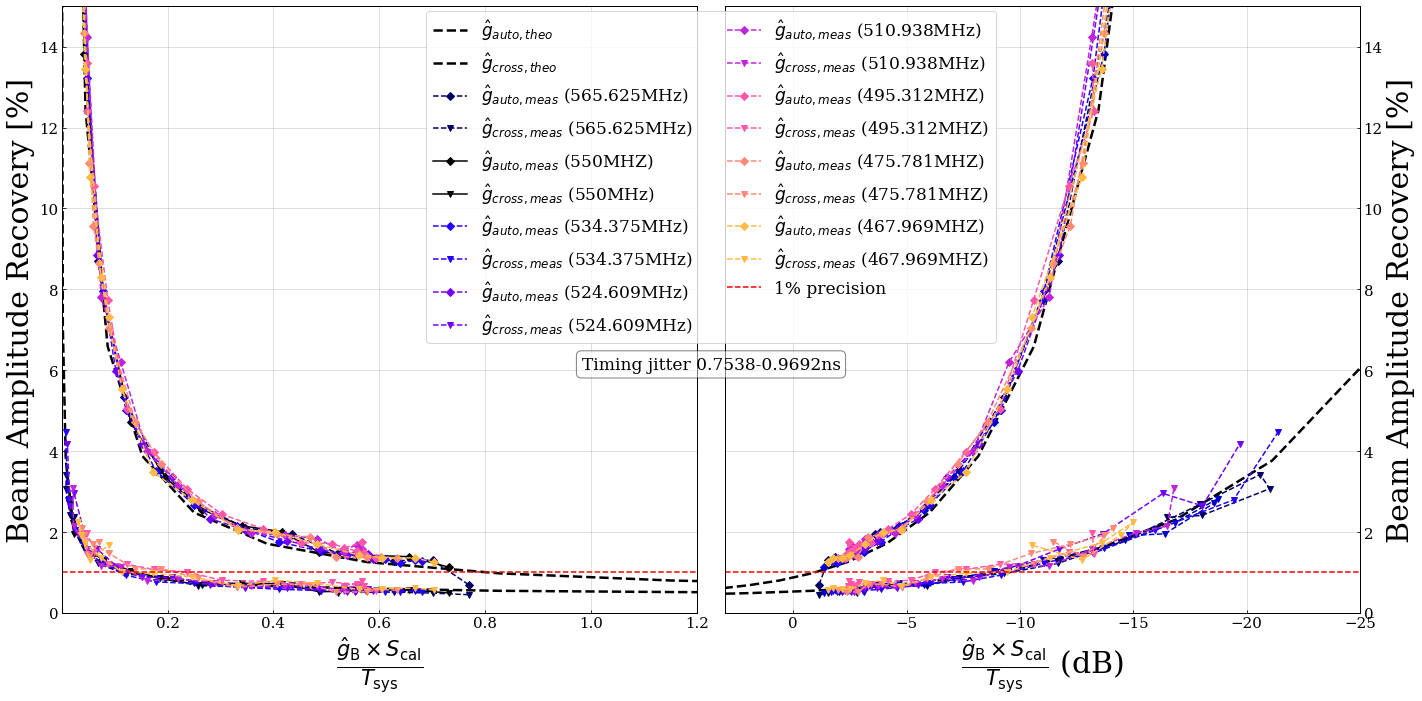

In [22]:
##dns simulations -- beam amplitude recovery in presence of timing noise 

fman=727e6 #select freq
t_length=65536 # 4*16384
inputpower=2**0 # this is 1
iteration_space=np.arange(10000) # total 10000 realizations 
jitter_space=np.hstack((np.array([0]),np.linspace(0.0e-9,1.4e-9,14))) # total 15 values 
#jitter_space=np.hstack((np.array([0]),np.linspace(1.4e-9,2.1e-9,8))) # total 9 values
gain_space=(np.linspace(0.05,1.2,15)**2.0) # total 30 values 

#Import a file -- loading saved data for (imapact of timing jitter) sims -- N 65536
dat=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/beam_amp_recovery_timing0-1.4ns_10000.npz")
#Assign the variables:
input_phase=dat['input_phase']
q_sig_scaling=dat['q_sig_scaling']
q_corr_scaling=dat['q_corr_scaling']
nq_max_ind_auto=dat['nq_max_ind_auto']
nq_max_mag_auto_on=dat['nq_max_mag_auto_on']
nq_max_mag_auto_off=dat['nq_max_mag_auto_off']
nq_max_ind_cross=dat['nq_max_ind_cross']
nq_max_mag_cross_on=dat['nq_max_mag_cross_on']
nq_max_mag_cross_off=dat['nq_max_mag_cross_off']
q_max_ind_auto=dat['q_max_ind_auto']
q_max_mag_auto_on=dat['q_max_mag_auto_on']
q_max_mag_auto_off=dat['q_max_mag_auto_off']
q_max_ind_cross=dat['q_max_ind_cross']
q_max_mag_cross_on=dat['q_max_mag_cross_on']
q_max_mag_cross_off=dat['q_max_mag_cross_off']
#Close the file:
dat.close()

q_a_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for autos 
q_c_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for crosses 
for j in range(len(jitter_space)):
    q_a_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*(q_corr_scaling[j,:,:]**2.0)*(t_length)*(np.outer((gain_space[:]**2.0),np.ones(len(iteration_space))))))
    q_c_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*q_corr_scaling[j,:,:]*q_sig_scaling[j,:,:]*(t_length)*(np.outer((gain_space[:]**1.0),np.ones(len(iteration_space))))))

# q_x -- error on autos; q_y -- error on crosses; q_z -- error on phase 
q_x=100.0*np.nanstd((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)/np.nanmean((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)
q_y=100.0*np.nanstd(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)/np.nanmean(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)
q_z=100.0*np.nanstd(-np.angle(nq_max_mag_cross_on[:,:,:]),axis=2)/(2.0*np.pi)

colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
#fig = plt.figure(figsize=[11,9])
#ax = plt.subplot(111)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

##Theoretical curves --
ax1.plot(gain_space*gain_space,q_x[8,:],linestyle= '--',linewidth=2.5, c=colorsarr[0],label=r'$\hat{g}_{auto,theo}$')
ax1.plot(gain_space*gain_space,q_y[8,:],linestyle= '--',linewidth=2.5, c=colorsarr[0],label=r'$\hat{g}_{cross,theo}$')

##Measured curves -- 
ax1.plot(gT_f1[8:24], errauto_f1[8:24], 'D--', c=colorsarr[100], label=r'$\hat{g}_{auto,meas}$ (565.625MHz)')
ax1.plot(gT_f1[8:24], errcross_f1[8:24], 'v--', c=colorsarr[100], label=r'$\hat{g}_{cross,meas}$ (565.625MHz)')
ax1.plot(gT_f2[8:24], errauto_f2[8:24], 'D-', c='black', label=r'$\hat{g}_{auto,meas}$ (550MHZ)')
ax1.plot(gT_f2[8:24], errcross_f2[8:24], 'v-', c='black', label=r'$\hat{g}_{cross,meas}$ (550MHz)')
ax1.plot(gT_f3[8:24], errauto_f3[8:24], 'D--', c=colorsarr[300], label=r'$\hat{g}_{auto,meas}$ (534.375MHz)')
ax1.plot(gT_f3[8:24], errcross_f3[8:24], 'v--', c=colorsarr[300], label=r'$\hat{g}_{cross,meas}$ (534.375MHz)')
ax1.plot(gT_f4[8:24], errauto_f4[8:24], 'D--', c=colorsarr[400], label=r'$\hat{g}_{auto,meas}$ (524.609MHz)')
ax1.plot(gT_f4[8:24], errcross_f4[8:24], 'v--', c=colorsarr[400], label=r'$\hat{g}_{cross,meas}$ (524.609MHz)')
ax1.plot(gT_f5[8:24], errauto_f5[8:24], 'D--', c=colorsarr[500], label=r'$\hat{g}_{auto,meas}$ (510.938MHz)')
ax1.plot(gT_f5[8:24], errcross_f5[8:24], 'v--', c=colorsarr[500], label=r'$\hat{g}_{cross,meas}$ (510.938MHz)')
ax1.plot(gT_f6[8:24], errauto_f6[8:24], 'D--', c=colorsarr[600], label=r'$\hat{g}_{auto,meas}$ (495.312MHZ)')
ax1.plot(gT_f6[8:24], errcross_f6[8:24], 'v--', c=colorsarr[600], label=r'$\hat{g}_{cross,meas}$ (495.312MHZ)')
ax1.plot(gT_f7[8:24], errauto_f7[8:24], 'D--', c=colorsarr[700], label=r'$\hat{g}_{auto,meas}$ (475.781MHZ)')
ax1.plot(gT_f7[8:24], errcross_f7[8:24], 'v--', c=colorsarr[700], label=r'$\hat{g}_{cross,meas}$ (475.781MHZ)')
ax1.plot(gT_f8[8:24], errauto_f8[8:24], 'D--', c=colorsarr[800], label=r'$\hat{g}_{auto,meas}$ (467.969MHZ)')
ax1.plot(gT_f8[8:24], errcross_f8[8:24], 'v--', c=colorsarr[800], label=r'$\hat{g}_{cross,meas}$ (467.969MHZ)')
ax1.axhline(y = 1, color = 'r', linestyle = '--', label= "1% precision")
ax1.set_ylim(0,15)
ax1.set_xlim(0.00025,1.2)
ax1.grid(True)
ax1.set_xlabel(r'$\frac{\hat{g}_{\mathrm{B}} \times S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$', fontsize= 30) 
ax1.set_ylabel('Beam Amplitude Recovery [%]', fontsize= 30)

##Theoretical curves in log space --
ax2.plot(10*np.log10(gain_space*gain_space),q_x[8,:],linestyle= '--',linewidth=2.5, c=colorsarr[0],label='Autocorr-theo')
ax2.plot(10*np.log10(gain_space*gain_space),q_y[8,:],linestyle= '--',linewidth=2.5, c=colorsarr[0],label='Crosscorr-theo')

##Measured curves in log space -- 
ax2.plot(10*np.log10(gT_f1[8:24]), errauto_f1[8:24], 'D--', c=colorsarr[100], label=f'Autocorr-meas (Freq index = 600)')
ax2.plot(10*np.log10(gT_f1[8:24]), errcross_f1[8:24], 'v--', c=colorsarr[100], label=f'Crosscorr-meas (Freq index = 600)')
ax2.plot(10*np.log10(gT_f2[8:24]), errauto_f2[8:24], 'D--', c=colorsarr[200], label=f'Autocorr-meas (Freq index = 640)')
ax2.plot(10*np.log10(gT_f2[8:24]), errcross_f2[8:24], 'v--', c=colorsarr[200], label=f'Crosscorr-meas (Freq index = 640)')
ax2.plot(10*np.log10(gT_f3[8:24]), errauto_f3[8:24], 'D--', c=colorsarr[300], label=f'Autocorr-meas (Freq index = 680)')
ax2.plot(10*np.log10(gT_f3[8:24]), errcross_f3[8:24], 'v--', c=colorsarr[300], label=f'Crosscorr-meas (Freq index = 680)')
ax2.plot(10*np.log10(gT_f4[8:24]), errauto_f4[8:24], 'D--', c=colorsarr[400], label=f'Autocorr-meas (Freq index = 705)')
ax2.plot(10*np.log10(gT_f4[8:24]), errcross_f4[8:24], 'v--', c=colorsarr[400], label=f'Crosscorr-meas (Freq index = 705)')
ax2.plot(10*np.log10(gT_f5[8:24]), errauto_f5[8:24], 'D--', c=colorsarr[500], label=f'Autocorr-meas (Freq index = 740)')
ax2.plot(10*np.log10(gT_f5[8:24]), errcross_f5[8:24], 'v--', c=colorsarr[500], label=f'Crosscorr-meas (Freq index = 740)')
ax2.plot(10*np.log10(gT_f6[8:24]), errauto_f6[8:24], 'D--', c=colorsarr[600], label=f'Autocorr-meas (Freq index = 780)')
ax2.plot(10*np.log10(gT_f6[8:24]), errcross_f6[8:24], 'v--', c=colorsarr[600], label=f'Crosscorr-meas (Freq index = 780)')
ax2.plot(10*np.log10(gT_f7[8:24]), errauto_f7[8:24], 'D--', c=colorsarr[700], label=f'Autocorr-meas (Freq index = 830)')
ax2.plot(10*np.log10(gT_f7[8:24]), errcross_f7[8:24], 'v--', c=colorsarr[700], label=f'Crosscorr-meas (Freq index = 830)')
ax2.plot(10*np.log10(gT_f8[8:24]), errauto_f8[8:24], 'D--', c=colorsarr[800], label=f'Autocorr-meas (Freq index = 850)')
ax2.plot(10*np.log10(gT_f8[8:24]), errcross_f8[8:24], 'v--', c=colorsarr[800], label=f'Crosscorr-meas (Freq index = 850)')
plt.axhline(y = 1, color = 'r', linestyle = '--', label= "1% precision")
ax2.set_ylim(0,15)
ax2.set_xlim(-25,3)
ax2.grid(True)
ax2.set_xlabel(r'$\frac{\hat{g}_{\mathrm{B}} \times S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$ (dB)', fontsize= 30) 
ax2.invert_xaxis()
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set_ylabel('Beam Amplitude Recovery [%]', fontsize= 30)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, 0.74), 
           ncol=2, fontsize=17)  # Adjust y-position as needed
fig.text(0.5, 0.48, f"Timing jitter {jitter_space[8]*(10**9):.4f}-{jitter_space[10]*(10**9):.4f}ns",
         ha='center', va='center', fontsize=17, bbox=dict(boxstyle='round', facecolor='white', 
        edgecolor='black', alpha=0.5))
fig.tight_layout()

fig.savefig('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/beam_amp_recovery_curves/beam_amp_curves_for_publication/beam_amp_recovery.pdf', 
            dpi=300)
plt.show()


In [ ]:
##dns simulations -- beam amplitude recovery in presence of timing noise 

fman=727e6 #select freq
t_length=65536 # 4*16384
inputpower=2**0 # this is 1
iteration_space=np.arange(10000) # total 10000 realizations 
jitter_space=np.hstack((np.array([0]),np.linspace(0.0e-9,1.4e-9,14))) # total 15 values 
#jitter_space=np.hstack((np.array([0]),np.linspace(1.4e-9,2.1e-9,8))) # total 9 values
gain_space=(np.linspace(0.05,1.2,15)**2.0) # total 30 values 

#Import a file -- loading saved data for (imapact of timing jitter) sims -- N 65536
dat=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/beam_amp_recovery_timing0-1.4ns_10000.npz")
#Assign the variables:
input_phase=dat['input_phase']
q_sig_scaling=dat['q_sig_scaling']
q_corr_scaling=dat['q_corr_scaling']
nq_max_ind_auto=dat['nq_max_ind_auto']
nq_max_mag_auto_on=dat['nq_max_mag_auto_on']
nq_max_mag_auto_off=dat['nq_max_mag_auto_off']
nq_max_ind_cross=dat['nq_max_ind_cross']
nq_max_mag_cross_on=dat['nq_max_mag_cross_on']
nq_max_mag_cross_off=dat['nq_max_mag_cross_off']
q_max_ind_auto=dat['q_max_ind_auto']
q_max_mag_auto_on=dat['q_max_mag_auto_on']
q_max_mag_auto_off=dat['q_max_mag_auto_off']
q_max_ind_cross=dat['q_max_ind_cross']
q_max_mag_cross_on=dat['q_max_mag_cross_on']
q_max_mag_cross_off=dat['q_max_mag_cross_off']
#Close the file:
dat.close()

q_a_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for autos 
q_c_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for crosses 
for j in range(len(jitter_space)):
    q_a_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*(q_corr_scaling[j,:,:]**2.0)*(t_length)*(np.outer((gain_space[:]**2.0),np.ones(len(iteration_space))))))
    q_c_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*q_corr_scaling[j,:,:]*q_sig_scaling[j,:,:]*(t_length)*(np.outer((gain_space[:]**1.0),np.ones(len(iteration_space))))))

# q_x -- error on autos; q_y -- error on crosses; q_z -- error on phase 
q_x=100.0*np.nanstd((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)/np.nanmean((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)
q_y=100.0*np.nanstd(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)/np.nanmean(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)
q_z=100.0*np.nanstd(-np.angle(nq_max_mag_cross_on[:,:,:]),axis=2)/(2.0*np.pi)


colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
fig = plt.figure(figsize=[11,9])
ax = plt.subplot(111)

##Theoretical curves --
ax.plot(10*np.log10(gain_space*gain_space),q_x[8,:],linestyle= '--',linewidth=2.5, c=colorsarr[0],label='Autocorr-theo')
ax.plot(10*np.log10(gain_space*gain_space),q_y[8,:],linestyle= '--',linewidth=2.5, c=colorsarr[0],label='Crosscorr-theo')

##Measured curves -- 
ax.plot(10*np.log10(gT_f1[8:24]), errauto_f1[8:24], 'D--', c=colorsarr[100], label=f'Autocorr-meas (Freq index = 600)')
ax.plot(10*np.log10(gT_f1[8:24]), errcross_f1[8:24], 'v--', c=colorsarr[100], label=f'Crosscorr-meas (Freq index = 600)')
ax.plot(10*np.log10(gT_f2[8:24]), errauto_f2[8:24], 'D--', c=colorsarr[200], label=f'Autocorr-meas (Freq index = 640)')
ax.plot(10*np.log10(gT_f2[8:24]), errcross_f2[8:24], 'v--', c=colorsarr[200], label=f'Crosscorr-meas (Freq index = 640)')
ax.plot(10*np.log10(gT_f3[8:24]), errauto_f3[8:24], 'D--', c=colorsarr[300], label=f'Autocorr-meas (Freq index = 680)')
ax.plot(10*np.log10(gT_f3[8:24]), errcross_f3[8:24], 'v--', c=colorsarr[300], label=f'Crosscorr-meas (Freq index = 680)')
ax.plot(10*np.log10(gT_f4[8:24]), errauto_f4[8:24], 'D--', c=colorsarr[400], label=f'Autocorr-meas (Freq index = 705)')
ax.plot(10*np.log10(gT_f4[8:24]), errcross_f4[8:24], 'v--', c=colorsarr[400], label=f'Crosscorr-meas (Freq index = 705)')
ax.plot(10*np.log10(gT_f5[8:24]), errauto_f5[8:24], 'D--', c=colorsarr[500], label=f'Autocorr-meas (Freq index = 740)')
ax.plot(10*np.log10(gT_f5[8:24]), errcross_f5[8:24], 'v--', c=colorsarr[500], label=f'Crosscorr-meas (Freq index = 740)')
ax.plot(10*np.log10(gT_f6[8:24]), errauto_f6[8:24], 'D--', c=colorsarr[600], label=f'Autocorr-meas (Freq index = 780)')
ax.plot(10*np.log10(gT_f6[8:24]), errcross_f6[8:24], 'v--', c=colorsarr[600], label=f'Crosscorr-meas (Freq index = 780)')
ax.plot(10*np.log10(gT_f7[8:24]), errauto_f7[8:24], 'D--', c=colorsarr[700], label=f'Autocorr-meas (Freq index = 830)')
ax.plot(10*np.log10(gT_f7[8:24]), errcross_f7[8:24], 'v--', c=colorsarr[700], label=f'Crosscorr-meas (Freq index = 830)')
ax.plot(10*np.log10(gT_f8[8:24]), errauto_f8[8:24], 'D--', c=colorsarr[800], label=f'Autocorr-meas (Freq index = 850)')
ax.plot(10*np.log10(gT_f8[8:24]), errcross_f8[8:24], 'v--', c=colorsarr[800], label=f'Crosscorr-meas (Freq index = 850)')
plt.axhline(y = 1, color = 'r', linestyle = '--', label= "1% precision")
plt.ylim(0,15)
plt.xlim(-25,3)
ax.grid(True)
#ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.01), fontsize= 13)
plt.xlabel(r'$\frac{\hat{g}_{\mathrm{B}} \times S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$ (dB)', fontsize= 25) 
plt.ylabel('Beam Amplitude Recovery [%]', fontsize= 20)
#plt.savefig('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/beam_amp_recovery_curves/beam_amp_curves_for_publication/beam_amp_recovery_log.pdf', 
#            dpi=300)


In [ ]:
##dns simulations -- beam amp recovery in presence of noise 

#Import a file -- loading saved data for (impact of noise) sims -- N 65536
data=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/gain_sweep_10000.npz")
#Assign the variables:
gain_auto_quant= data['gain_auto_quant'] 
gain_cross_quant= data['gain_cross_quant'] 
gains= data['gains'] 
## Close the file:
data.close()

#Normalizing the data with gains -- N 65536
int_time =4*16384 
gain_auto_quant_std = (gain_auto_quant/(2*int_time*gains*gains)).std(axis=0)[:len(gains)]
gain_cross_quant_std = (gain_cross_quant/(2*int_time*gains)).std(axis=0)[:len(gains)]
gain_auto_qaunt_mean= (gain_auto_quant/(2*int_time*gains*gains)).mean(axis=0)[:len(gains)]
gain_cross_quant_mean = (gain_cross_quant/(2*int_time*gains)).mean(axis=0)[:len(gains)]

##dns simulations -- beam amplitude recovery in presence of timing noise 

fman=727e6 #select freq
t_length=65536 # 4*16384
inputpower=2**0 # this is 1
iteration_space=np.arange(10000) # total 10000 realizations 
jitter_space=np.hstack((np.array([0]),np.linspace(0.0e-9,1.4e-9,14))) # total 15 values 
#jitter_space=np.hstack((np.array([0]),np.linspace(1.4e-9,2.1e-9,8))) # total 9 values
gain_space=(np.linspace(0.05,1.2,15)**2.0) # total 30 values 

#Import a file -- loading saved data for (imapact of timing jitter) sims -- N 65536
dat=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/beam_amp_recovery_timing0-1.4ns_10000.npz")
#Assign the variables:
input_phase=dat['input_phase']
q_sig_scaling=dat['q_sig_scaling']
q_corr_scaling=dat['q_corr_scaling']
nq_max_ind_auto=dat['nq_max_ind_auto']
nq_max_mag_auto_on=dat['nq_max_mag_auto_on']
nq_max_mag_auto_off=dat['nq_max_mag_auto_off']
nq_max_ind_cross=dat['nq_max_ind_cross']
nq_max_mag_cross_on=dat['nq_max_mag_cross_on']
nq_max_mag_cross_off=dat['nq_max_mag_cross_off']
q_max_ind_auto=dat['q_max_ind_auto']
q_max_mag_auto_on=dat['q_max_mag_auto_on']
q_max_mag_auto_off=dat['q_max_mag_auto_off']
q_max_ind_cross=dat['q_max_ind_cross']
q_max_mag_cross_on=dat['q_max_mag_cross_on']
q_max_mag_cross_off=dat['q_max_mag_cross_off']
#Close the file:
dat.close()

q_a_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for autos 
q_c_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for crosses 
for j in range(len(jitter_space)):
    q_a_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*(q_corr_scaling[j,:,:]**2.0)*(t_length)*(np.outer((gain_space[:]**2.0),np.ones(len(iteration_space))))))
    q_c_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*q_corr_scaling[j,:,:]*q_sig_scaling[j,:,:]*(t_length)*(np.outer((gain_space[:]**1.0),np.ones(len(iteration_space))))))

# q_x -- error on autos; q_y -- error on crosses; q_z -- error on phase 
q_x=100.0*np.nanstd((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)/np.nanmean((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)
q_y=100.0*np.nanstd(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)/np.nanmean(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)
q_z=100.0*np.nanstd(-np.angle(nq_max_mag_cross_on[:,:,:]),axis=2)/(2.0*np.pi)
#print('jitter space is given as: {}'.format(jitter_space))

#Plot of 10000 realizations used for DNS paper along with implementation results -- beam amplitude recovery (%)
dim1 = math.floor(math.sqrt(len(freq_arr)))
dim2 = math.ceil(len(freq_arr)/dim1)
ax = plt.subplot(dim2,dim1,index+1)

ax.plot(gain_space*gain_space,q_x[8,:],linestyle= ':',c=colorsarr[750],label='Autocorr-theo')
ax.plot(gain_space*gain_space,q_y[8,:],linestyle= ':',c=colorsarr[400],label='Crosscorr-theo')
ax.plot(g_T[6:21], err_cross_percent[6:21], 'v--', c=colorsarr[300], label='Crosscorr-meas')
ax.plot(g_T[6:21], err_auto_percent[6:21], 'D--', c=colorsarr[100], label='Autocorr-meas')

plt.axhline(y = 1, color = 'r', linestyle = '--', label= "1% precision")
plt.axvline(x = 0.12, c=colorsarr[50], ymin=0.0, ymax=0.07, linestyle = '--')
x=0.117
plt.text(x, 0.3, f'gT = {x:.2f}', ha='right', va='bottom', fontsize=17, color=colorsarr[100])
plt.text(0.63, 11.2, f"Frequency bin {f_ind} i.e. {freq:.3f}MHZ", # x, y in data coords
         fontsize=15, bbox=dict(boxstyle='round', #'round', 'square', 'round4', etc.
         facecolor='white', edgecolor='black', alpha=0.5))
plt.text(0.765, 10.5, f"Timing jitter {jitter_space[8]*(10**9):.4f}ns", # x, y in data coords
         fontsize=15, bbox=dict(boxstyle='round', #'round', 'square', 'round4', etc.
         facecolor='white', edgecolor='black', alpha=0.5))
plt.ylim(0,15)
plt.xlim(0.00025,1)
plt.xlabel(r'$\frac{\hat{g}_{\mathrm{B}} \times S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$', fontsize= 25) 
plt.ylabel('Beam Amplitude Recovery [%]', fontsize= 20)
plt.grid(True)
plt.legend(fontsize= 17)

#plt.tight_layout()
#plt.savefig(f'/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/beam_amp_recovery_curves/MB_theo_pract/fbin{f_ind}.png',dpi=300)


In [ ]:
def beam_amp_recovery_cont(freq_arr):
    """Function to plot beam amplitude recovery (%)of continuous source:
    
    Parameters
    ----------
    
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels
    """
    
    colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
    fig = plt.figure(figsize=[20,20])
    for index,f_ind in enumerate(freq_arr):
        
        avgs=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/June9...246Z/stats/means_fbin{}.npz".format(f_ind))
        stds=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/June9...246Z/stats/stds_fbin{}.npz".format(f_ind))
        
        """stats from saved files -- N 65536 (steps of 5 degrees) (range -50 t0 130)
        autos and crosses means, std dev and variances lists -- correlator data 
        
        Parameters
        ----------

        autos_0x0 -- <VV*>t,ON
        autos_0x0_off -- <VV*>t,OFF
        crosses_0x1 -- <VtVref*>ON
        autos_1x1 -- <VV*>ref,ON 
        autos_1x1_off -- <VV*>ref,OFF (which is 0 in this case) 
        """
        
        autos_0x0 = [avgs['avgs130n'][0], avgs['avgs125n'][0], avgs['avgs120n'][0], avgs['avgs115n'][0], avgs['avgs110n'][0], avgs['avgs105n'][0], avgs['avgs100n'][0], avgs['avgs95n'][0], avgs['avgs90n'][0], avgs['avgs85n'][0], avgs['avgs80n'][0], avgs['avgs75n'][0], avgs['avgs70n'][0], avgs['avgs65n'][0], avgs['avgs60n'][0], avgs['avgs55n'][0], avgs['avgs50n'][0], avgs['avgs45n'][0], avgs['avgs40n'][0], avgs['avgs35n'][0], avgs['avgs30n'][0], avgs['avgs25n'][0], avgs['avgs20n'][0], avgs['avgs15n'][0], avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0], avgs['avgs15p'][0], avgs['avgs20p'][0], avgs['avgs25p'][0], avgs['avgs30p'][0], avgs['avgs35p'][0], avgs['avgs40p'][0], avgs['avgs45p'][0], avgs['avgs50p'][0], avgs['avgs55p'][0], avgs['avgs60p'][0], avgs['avgs65p'][0], avgs['avgs70p'][0], avgs['avgs75p'][0], avgs['avgs80p'][0], avgs['avgs85p'][0], avgs['avgs90p'][0], avgs['avgs95p'][0], avgs['avgs100p'][0], avgs['avgs105p'][0], avgs['avgs110p'][0], avgs['avgs115p'][0], avgs['avgs120p'][0], avgs['avgs125p'][0], avgs['avgs130p'][0]]
        crosses_0x1 = [avgs['avgs130n'][1], avgs['avgs125n'][1], avgs['avgs120n'][1], avgs['avgs115n'][1], avgs['avgs110n'][1], avgs['avgs105n'][1], avgs['avgs100n'][1], avgs['avgs95n'][1], avgs['avgs90n'][1], avgs['avgs85n'][1], avgs['avgs80n'][1], avgs['avgs75n'][1], avgs['avgs70n'][1], avgs['avgs65n'][1], avgs['avgs60n'][1], avgs['avgs55n'][1], avgs['avgs50n'][1], avgs['avgs45n'][1], avgs['avgs40n'][1], avgs['avgs35n'][1], avgs['avgs30n'][1], avgs['avgs25n'][1], avgs['avgs20n'][1], avgs['avgs15n'][1], avgs['avgs10n'][1], avgs['avgs5n'][1], avgs['avgs0'][1], avgs['avgs5p'][1], avgs['avgs10p'][1], avgs['avgs15p'][1], avgs['avgs20p'][1], avgs['avgs25p'][1], avgs['avgs30p'][1], avgs['avgs35p'][1], avgs['avgs40p'][1], avgs['avgs45p'][1], avgs['avgs50p'][1], avgs['avgs55p'][1], avgs['avgs60p'][1], avgs['avgs65p'][1], avgs['avgs70p'][1], avgs['avgs75p'][1], avgs['avgs80p'][1], avgs['avgs85p'][1], avgs['avgs90p'][1], avgs['avgs95p'][1], avgs['avgs100p'][1], avgs['avgs105p'][1], avgs['avgs110p'][1], avgs['avgs115p'][1], avgs['avgs120p'][1], avgs['avgs125p'][1], avgs['avgs130p'][1]]
        autos_1x1 = [avgs['avgs130n'][2], avgs['avgs125n'][2], avgs['avgs120n'][2], avgs['avgs115n'][2], avgs['avgs110n'][2], avgs['avgs105n'][2], avgs['avgs100n'][2], avgs['avgs95n'][2], avgs['avgs90n'][2], avgs['avgs85n'][2], avgs['avgs80n'][2], avgs['avgs75n'][2], avgs['avgs70n'][2], avgs['avgs65n'][2], avgs['avgs60n'][2], avgs['avgs55n'][2], avgs['avgs50n'][2], avgs['avgs45n'][2], avgs['avgs40n'][2], avgs['avgs35n'][2], avgs['avgs30n'][2], avgs['avgs25n'][2], avgs['avgs20n'][2], avgs['avgs15n'][2], avgs['avgs10n'][2], avgs['avgs5n'][2], avgs['avgs0'][2], avgs['avgs5p'][2], avgs['avgs10p'][2], avgs['avgs15p'][2], avgs['avgs20p'][2], avgs['avgs25p'][2], avgs['avgs30p'][2], avgs['avgs35p'][2], avgs['avgs40p'][2], avgs['avgs45p'][2], avgs['avgs50p'][2], avgs['avgs55p'][2], avgs['avgs60p'][2], avgs['avgs65p'][2], avgs['avgs70p'][2], avgs['avgs75p'][2], avgs['avgs80p'][2], avgs['avgs85p'][2], avgs['avgs90p'][2], avgs['avgs95p'][2], avgs['avgs100p'][2], avgs['avgs105p'][2], avgs['avgs110p'][2], avgs['avgs115p'][2], avgs['avgs120p'][2], avgs['avgs125p'][2], avgs['avgs130p'][2]]

        stddev_cross0x1 = [stds['stds130n'][1], stds['stds125n'][1], stds['stds120n'][1], stds['stds115n'][1], stds['stds110n'][1], stds['stds105n'][1], stds['stds100n'][1], stds['stds95n'][1], stds['stds90n'][1], stds['stds85n'][1], stds['stds80n'][1], stds['stds75n'][1], stds['stds70n'][1], stds['stds65n'][1], stds['stds60n'][1], stds['stds55n'][1], stds['stds50n'][1], stds['stds45n'][1], stds['stds40n'][1], stds['stds35n'][1], stds['stds30n'][1], stds['stds25n'][1], stds['stds20n'][1], stds['stds15n'][1], stds['stds10n'][1], stds['stds5n'][1], stds['stds0'][1], stds['stds5p'][1], stds['stds10p'][1], stds['stds15p'][1], stds['stds20p'][1], stds['stds25p'][1], stds['stds30p'][1], stds['stds35p'][1], stds['stds40p'][1], stds['stds45p'][1], stds['stds50p'][1], stds['stds55p'][1], stds['stds60p'][1], stds['stds65p'][1], stds['stds70p'][1], stds['stds75p'][1], stds['stds80p'][1], stds['stds85p'][1], stds['stds90p'][1], stds['stds95p'][1], stds['stds100p'][1], stds['stds105p'][1], stds['stds110p'][1], stds['stds115p'][1], stds['stds120p'][1], stds['stds125p'][1], stds['stds130p'][1]]

        freq=400+((1024-f_ind)*0.390625) 
        #print('Given frequency: {}MHz'.format(freq))

        # converting into numpy ndarray for arithmatic operations -- N 65536
        ## autos_0x0 -- <VV*>t,ON and # autos_1x1 -- <VV*>ref,ON 

        autos_0x0=np.array(autos_0x0)
        crosses_0x1=np.array(crosses_0x1)
        autos_1x1=np.array(autos_1x1)
        
        stddev_cross0x1=np.array(stddev_cross0x1)

        # sqrt of total integration period -- N 65536
        stddev_cross0x1 = stddev_cross0x1/2 
        
        # error for crosses -- std/mean -- N 65536 
        err_crosses = []
        err_cross_percent = []
        for i in np.arange(0,np.size(stddev_cross0x1)):
            err = stddev_cross0x1[i]/crosses_0x1[i]
            err_crosses.append(err)
            err_percent = (stddev_cross0x1[i]/crosses_0x1[i])*100
            err_cross_percent.append(err_percent)


        #gT= Scal/Tsys
        #Scal/Tsys=(Pon-Poff)/Poff
        #g_T = (autos_0x0 - autos_0x0_off) / autos_0x0_off
        #print("total gain values are: {}".format(len(g_T)))
        #print('Telescopic gains are: {}'.format(g_T))
        angles = np.arange(-130,135,5)

        #Plot of 10000 realizations used for DNS paper along with implementation results -- beam amplitude recovery (%)
        dim1 = math.floor(math.sqrt(len(freq_arr)))
        dim2 = math.ceil(len(freq_arr)/dim1)
        ax = plt.subplot(dim2,dim1,index+1)
        ax.plot(angles, err_cross_percent[:], 's', c=colorsarr[500], label='Crosscorr-pract')
        #plt.xlabel('$\hat{g_T}$', fontsize= 13) 
        plt.xlabel('angles', fontsize= 13) 
        plt.ylabel('Beam Amplitude Recovery [%]', fontsize= 13) 
        plt.axhline(y = 1, color = 'r', linestyle = '--', label= "1% threshold")
        #plt.axvline(x = 0.558, c=colorsarr[50], ymin=0.0, ymax=0.1, linestyle = '--')
        #plt.axvline(x = 0.665, c=colorsarr[50], ymin=0.0, ymax=0.1, linestyle = '--')

        plt.grid(True)
        ax.legend(fontsize= 13)
        plt.ylim(0,10)
        #plt.xlim(0.00025,1)
        plt.suptitle("Main beam amplitude recovery", fontsize=25)
        #plt.title(f"Freq bin {f_ind} ({freq} MHz) -- timing jitter {jitter_space[13]}ns", fontsize=15)
    plt.tight_layout()


In [ ]:
beam_amp_recovery_cont(freq_arr=[500,520,550,600,625,640,650])

In [ ]:
def plot_telescopic_gains(freq_arr):
    """Plot beam amplitude recovery (%) of the receiver system.
    
    Parameters
    ----------
    
    avgs2: averages of ON data points of individual correlator channel 
    avgs_off2: averages of OFF data points of individual correlator channel
    g_T: Telescopic gain corresponding to beam angles
    
    """
    colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
    fig = plt.figure(figsize=[20,20])
    for index,f_ind in enumerate(freq_arr):
        
        avgs=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr11...307Z/stats/means_fbin{}.npz".format(f_ind))
        avgs_off=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr11...307Z/stats/means_off_fbin{}.npz".format(f_ind))
        
        """stats from saved files -- N 65536 (steps of 5 degrees) (range -50 to 130)
        autos and crosses means, std dev and variances lists-- correlator data 
        
        Parameters
        ----------

        autos_0x0 -- <VV*>t,ON
        autos_0x0_off -- <VV*>t,OFF
        """
        
        autos_0x0 = [avgs['avgs130n'][0], avgs['avgs125n'][0], avgs['avgs120n'][0], avgs['avgs115n'][0], avgs['avgs110n'][0], avgs['avgs105n'][0], avgs['avgs100n'][0], avgs['avgs95n'][0], avgs['avgs90n'][0], avgs['avgs85n'][0], avgs['avgs80n'][0], avgs['avgs75n'][0], avgs['avgs70n'][0], avgs['avgs65n'][0], avgs['avgs60n'][0], avgs['avgs55n'][0], avgs['avgs50n'][0], avgs['avgs45n'][0], avgs['avgs40n'][0], avgs['avgs35n'][0], avgs['avgs30n'][0], avgs['avgs25n'][0], avgs['avgs20n'][0], avgs['avgs15n'][0], avgs['avgs10n'][0], avgs['avgs5n'][0], avgs['avgs0'][0], avgs['avgs5p'][0], avgs['avgs10p'][0], avgs['avgs15p'][0], avgs['avgs20p'][0], avgs['avgs25p'][0], avgs['avgs30p'][0], avgs['avgs35p'][0], avgs['avgs40p'][0], avgs['avgs45p'][0], avgs['avgs50p'][0], avgs['avgs55p'][0], avgs['avgs60p'][0], avgs['avgs65p'][0], avgs['avgs70p'][0], avgs['avgs75p'][0], avgs['avgs80p'][0], avgs['avgs85p'][0], avgs['avgs90p'][0], avgs['avgs95p'][0], avgs['avgs100p'][0], avgs['avgs105p'][0], avgs['avgs110p'][0], avgs['avgs115p'][0], avgs['avgs120p'][0], avgs['avgs125p'][0], avgs['avgs130p'][0]]
        autos_0x0_off = [avgs_off['avgs_off130n'][0], avgs_off['avgs_off125n'][0], avgs_off['avgs_off120n'][0], avgs_off['avgs_off115n'][0], avgs_off['avgs_off110n'][0], avgs_off['avgs_off105n'][0], avgs_off['avgs_off100n'][0], avgs_off['avgs_off95n'][0], avgs_off['avgs_off90n'][0], avgs_off['avgs_off85n'][0], avgs_off['avgs_off80n'][0], avgs_off['avgs_off75n'][0], avgs_off['avgs_off70n'][0], avgs_off['avgs_off65n'][0], avgs_off['avgs_off60n'][0], avgs_off['avgs_off55n'][0], avgs_off['avgs_off50n'][0], avgs_off['avgs_off45n'][0], avgs_off['avgs_off40n'][0], avgs_off['avgs_off35n'][0], avgs_off['avgs_off30n'][0], avgs_off['avgs_off25n'][0], avgs_off['avgs_off20n'][0], avgs_off['avgs_off15n'][0], avgs_off['avgs_off10n'][0], avgs_off['avgs_off5n'][0], avgs_off['avgs_off0'][0], avgs_off['avgs_off5p'][0], avgs_off['avgs_off10p'][0], avgs_off['avgs_off15p'][0], avgs_off['avgs_off20p'][0], avgs_off['avgs_off25p'][0], avgs_off['avgs_off30p'][0], avgs_off['avgs_off35p'][0], avgs_off['avgs_off40p'][0], avgs_off['avgs_off45p'][0], avgs_off['avgs_off50p'][0], avgs_off['avgs_off55p'][0], avgs_off['avgs_off60p'][0], avgs_off['avgs_off65p'][0], avgs_off['avgs_off70p'][0], avgs_off['avgs_off75p'][0], avgs_off['avgs_off80p'][0], avgs_off['avgs_off85p'][0], avgs_off['avgs_off90p'][0], avgs_off['avgs_off95p'][0], avgs_off['avgs_off100p'][0], avgs_off['avgs_off105p'][0], avgs_off['avgs_off110p'][0], avgs_off['avgs_off115p'][0], avgs_off['avgs_off120p'][0], avgs_off['avgs_off125p'][0], avgs_off['avgs_off130p'][0]]
          
        # converting into numpy ndarray for arithmatic operations -- N 65536
        autos_0x0=np.array(autos_0x0)
        autos_0x0_off=np.array(autos_0x0_off)
        
        freq=400+((1024-f_ind)*0.390625)
        print('Given frequency: {}MHz'.format(freq))
        
        #gT= Scal/Tsys= (Pon-Poff)/Poff
        g_T = (autos_0x0 - autos_0x0_off) / autos_0x0_off
        #print("total gain values are: {}".format(len(g_T)))
        print('Telescopic gains are: {}'.format(g_T))
        #plotting telescopic gains against angles 
        dim1 = math.floor(math.sqrt(len(freq_arr)))
        dim2 = math.ceil(len(freq_arr)/dim1)
        ax = plt.subplot(dim2,dim1,index+1)
        #angles = np.arange(-40,150,5) for chamber data
        angles = np.arange(-135,130,5)
        ax.plot(angles,g_T,'*--', c=colorsarr[f_ind-200])
        plt.xlabel('angles (in degrees)')
        plt.ylabel('$\hat{g_T}$')
        plt.title(f'freq bin {f_ind} i.e. {freq} MHz')
        plt.suptitle(f'Telescopic gains')
    plt.tight_layout()
        

In [ ]:
plot_telescopic_gains(freq_arr=[270,280,290,300,305,310])

In [ ]:
#loading from saved .npz files -- No of samples (N) 65536
avgs2=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/633Z...Mar192025/stats/means_fbin670.npz")
avgs_off2=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/633Z...Mar192025/stats/means_off_fbin670.npz")
stds2=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/633Z...Mar192025/stats/stds_fbin670.npz")
var2=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/633Z...Mar192025/stats/var_fbin670.npz")
var_off2=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/633Z...Mar192025/stats/var_off_fbin670.npz")

In [ ]:
## stats from saved files --  N 65536 (steps of 5 degrees) (range -130 t0 130)
# autos and crosses means, std dev and variances lists-- correlator data 

# when --> 
# autos_0x0 -- <VV*>t,ON
# autos_0x0_off -- <VV*>t,OFF
# crosses_0x1 -- <VtVref*>ON
# autos_1x1 -- <VV*>ref,ON 
# autos_1x1_off -- <VV*>ref,OFF (which is 0 in this case)

fbin = 865
autos_0x0_2 = [avgs2['avgs130n'][0], avgs2['avgs125n'][0], avgs2['avgs120n'][0], avgs2['avgs115n'][0], avgs2['avgs110n'][0], avgs2['avgs105n'][0], avgs2['avgs100n'][0], avgs2['avgs95n'][0], avgs2['avgs90n'][0], avgs2['avgs85n'][0], avgs2['avgs80n'][0], avgs2['avgs75n'][0], avgs2['avgs70n'][0], avgs2['avgs65n'][0], avgs2['avgs60n'][0], avgs2['avgs55n'][0], avgs2['avgs50n'][0], avgs2['avgs45n'][0], avgs2['avgs40n'][0], avgs2['avgs35n'][0], avgs2['avgs30n'][0], avgs2['avgs25n'][0], avgs2['avgs20n'][0], avgs2['avgs15n'][0], avgs2['avgs10n'][0], avgs2['avgs5n'][0], avgs2['avgs0'][0], avgs2['avgs5p'][0], avgs2['avgs10p'][0], avgs2['avgs15p'][0], avgs2['avgs20p'][0], avgs2['avgs25p'][0], avgs2['avgs30p'][0], avgs2['avgs35p'][0], avgs2['avgs40p'][0], avgs2['avgs45p'][0], avgs2['avgs50p'][0], avgs2['avgs55p'][0], avgs2['avgs60p'][0], avgs2['avgs65p'][0], avgs2['avgs70p'][0], avgs2['avgs75p'][0], avgs2['avgs80p'][0], avgs2['avgs85p'][0], avgs2['avgs90p'][0], avgs2['avgs95p'][0], avgs2['avgs100p'][0], avgs2['avgs105p'][0], avgs2['avgs110p'][0], avgs2['avgs115p'][0], avgs2['avgs120p'][0], avgs2['avgs125p'][0], avgs2['avgs130p'][0]]
autos_0x0_off_2 = [avgs_off2['avgs_off130n'][0], avgs_off2['avgs_off125n'][0], avgs_off2['avgs_off120n'][0], avgs_off2['avgs_off115n'][0], avgs_off2['avgs_off110n'][0], avgs_off2['avgs_off105n'][0], avgs_off2['avgs_off100n'][0], avgs_off2['avgs_off95n'][0], avgs_off2['avgs_off90n'][0], avgs_off2['avgs_off85n'][0], avgs_off2['avgs_off80n'][0], avgs_off2['avgs_off75n'][0], avgs_off2['avgs_off70n'][0], avgs_off2['avgs_off65n'][0], avgs_off2['avgs_off60n'][0], avgs_off2['avgs_off55n'][0], avgs_off2['avgs_off50n'][0], avgs_off2['avgs_off45n'][0], avgs_off2['avgs_off40n'][0], avgs_off2['avgs_off35n'][0], avgs_off2['avgs_off30n'][0], avgs_off2['avgs_off25n'][0], avgs_off2['avgs_off20n'][0], avgs_off2['avgs_off15n'][0], avgs_off2['avgs_off10n'][0], avgs_off2['avgs_off5n'][0], avgs_off2['avgs_off0'][0], avgs_off2['avgs_off5p'][0], avgs_off2['avgs_off10p'][0], avgs_off2['avgs_off15p'][0], avgs_off2['avgs_off20p'][0], avgs_off2['avgs_off25p'][0], avgs_off2['avgs_off30p'][0], avgs_off2['avgs_off35p'][0], avgs_off2['avgs_off40p'][0], avgs_off2['avgs_off45p'][0], avgs_off2['avgs_off50p'][0], avgs_off2['avgs_off55p'][0], avgs_off2['avgs_off60p'][0], avgs_off2['avgs_off65p'][0], avgs_off2['avgs_off70p'][0], avgs_off2['avgs_off75p'][0], avgs_off2['avgs_off80p'][0], avgs_off2['avgs_off85p'][0], avgs_off2['avgs_off90p'][0], avgs_off2['avgs_off95p'][0], avgs_off2['avgs_off100p'][0], avgs_off2['avgs_off105p'][0], avgs_off2['avgs_off110p'][0], avgs_off2['avgs_off115p'][0], avgs_off2['avgs_off120p'][0], avgs_off2['avgs_off125p'][0], avgs_off2['avgs_off130p'][0]]
crosses_0x1_2 = [avgs2['avgs130n'][1], avgs2['avgs125n'][1], avgs2['avgs120n'][1], avgs2['avgs115n'][1], avgs2['avgs110n'][1], avgs2['avgs105n'][1], avgs2['avgs100n'][1], avgs2['avgs95n'][1], avgs2['avgs90n'][1], avgs2['avgs85n'][1], avgs2['avgs80n'][1], avgs2['avgs75n'][1], avgs2['avgs70n'][1], avgs2['avgs65n'][1], avgs2['avgs60n'][1], avgs2['avgs55n'][1], avgs2['avgs50n'][1], avgs2['avgs45n'][1], avgs2['avgs40n'][1], avgs2['avgs35n'][1], avgs2['avgs30n'][1], avgs2['avgs25n'][1], avgs2['avgs20n'][1], avgs2['avgs15n'][1], avgs2['avgs10n'][1], avgs2['avgs5n'][1], avgs2['avgs0'][1], avgs2['avgs5p'][1], avgs2['avgs10p'][1], avgs2['avgs15p'][1], avgs2['avgs20p'][1], avgs2['avgs25p'][1], avgs2['avgs30p'][1], avgs2['avgs35p'][1], avgs2['avgs40p'][1], avgs2['avgs45p'][1], avgs2['avgs50p'][1], avgs2['avgs55p'][1], avgs2['avgs60p'][1], avgs2['avgs65p'][1], avgs2['avgs70p'][1], avgs2['avgs75p'][1], avgs2['avgs80p'][1], avgs2['avgs85p'][1], avgs2['avgs90p'][1], avgs2['avgs95p'][1], avgs2['avgs100p'][1], avgs2['avgs105p'][1], avgs2['avgs110p'][1], avgs2['avgs115p'][1], avgs2['avgs120p'][1], avgs2['avgs125p'][1], avgs2['avgs130p'][1]]
autos_1x1_2 = [avgs2['avgs130n'][2], avgs2['avgs125n'][2], avgs2['avgs120n'][2], avgs2['avgs115n'][2], avgs2['avgs110n'][2], avgs2['avgs105n'][2], avgs2['avgs100n'][2], avgs2['avgs95n'][2], avgs2['avgs90n'][2], avgs2['avgs85n'][2], avgs2['avgs80n'][2], avgs2['avgs75n'][2], avgs2['avgs70n'][2], avgs2['avgs65n'][2], avgs2['avgs60n'][2], avgs2['avgs55n'][2], avgs2['avgs50n'][2], avgs2['avgs45n'][2], avgs2['avgs40n'][2], avgs2['avgs35n'][2], avgs2['avgs30n'][2], avgs2['avgs25n'][2], avgs2['avgs20n'][2], avgs2['avgs15n'][2], avgs2['avgs10n'][2], avgs2['avgs5n'][2], avgs2['avgs0'][2], avgs2['avgs5p'][2], avgs2['avgs10p'][2], avgs2['avgs15p'][2], avgs2['avgs20p'][2], avgs2['avgs25p'][2], avgs2['avgs30p'][2], avgs2['avgs35p'][2], avgs2['avgs40p'][2], avgs2['avgs45p'][2], avgs2['avgs50p'][2], avgs2['avgs55p'][2], avgs2['avgs60p'][2], avgs2['avgs65p'][2], avgs2['avgs70p'][2], avgs2['avgs75p'][2], avgs2['avgs80p'][2], avgs2['avgs85p'][2], avgs2['avgs90p'][2], avgs2['avgs95p'][2], avgs2['avgs100p'][2], avgs2['avgs105p'][2], avgs2['avgs110p'][2], avgs2['avgs115p'][2], avgs2['avgs120p'][2], avgs2['avgs125p'][2], avgs2['avgs130p'][2]]

var_auto0x0_2 = [var2['var130n'][0], var2['var125n'][0], var2['var120n'][0], var2['var115n'][0], var2['var110n'][0], var2['var105n'][0], var2['var100n'][0], var2['var95n'][0], var2['var90n'][0], var2['var85n'][0], var2['var80n'][0], var2['var75n'][0], var2['var70n'][0], var2['var65n'][0], var2['var60n'][0], var2['var55n'][0], var2['var50n'][0], var2['var45n'][0], var2['var40n'][0], var2['var35n'][0], var2['var30n'][0], var2['var25n'][0], var2['var20n'][0], var2['var15n'][0], var2['var10n'][0], var2['var5n'][0], var2['var0'][0], var2['var5p'][0], var2['var10p'][0], var2['var15p'][0], var2['var20p'][0], var2['var25p'][0], var2['var30p'][0], var2['var35p'][0], var2['var40p'][0], var2['var45p'][0], var2['var50p'][0], var2['var55p'][0], var2['var60p'][0], var2['var65p'][0], var2['var70p'][0], var2['var75p'][0], var2['var80p'][0], var2['var85p'][0], var2['var90p'][0], var2['var95p'][0], var2['var100p'][0], var2['var105p'][0], var2['var110p'][0], var2['var115p'][0], var2['var120p'][0], var2['var125p'][0], var2['var130p'][0]]
var_auto0x0_off_2 = [var_off2['var_off130n'][0], var_off2['var_off125n'][0], var_off2['var_off120n'][0], var_off2['var_off115n'][0], var_off2['var_off110n'][0], var_off2['var_off105n'][0], var_off2['var_off100n'][0], var_off2['var_off95n'][0], var_off2['var_off90n'][0], var_off2['var_off85n'][0], var_off2['var_off80n'][0], var_off2['var_off75n'][0], var_off2['var_off70n'][0], var_off2['var_off65n'][0], var_off2['var_off60n'][0], var_off2['var_off55n'][0], var_off2['var_off50n'][0], var_off2['var_off45n'][0], var_off2['var_off40n'][0], var_off2['var_off35n'][0], var_off2['var_off30n'][0], var_off2['var_off25n'][0], var_off2['var_off20n'][0], var_off2['var_off15n'][0], var_off2['var_off10n'][0], var_off2['var_off5n'][0], var_off2['var_off0'][0], var_off2['var_off5p'][0], var_off2['var_off10p'][0], var_off2['var_off15p'][0], var_off2['var_off20p'][0], var_off2['var_off25p'][0], var_off2['var_off30p'][0], var_off2['var_off35p'][0], var_off2['var_off40p'][0], var_off2['var_off45p'][0], var_off2['var_off50p'][0], var_off2['var_off55p'][0], var_off2['var_off60p'][0], var_off2['var_off65p'][0], var_off2['var_off70p'][0], var_off2['var_off75p'][0], var_off2['var_off80p'][0], var_off2['var_off85p'][0], var_off2['var_off90p'][0], var_off2['var_off95p'][0], var_off2['var_off100p'][0], var_off2['var_off105p'][0], var_off2['var_off110p'][0], var_off2['var_off115p'][0], var_off2['var_off120p'][0], var_off2['var_off125p'][0], var_off2['var_off130p'][0]]
var_auto1x1_2 = [var2['var130n'][2], var2['var125n'][2], var2['var120n'][2], var2['var115n'][2], var2['var110n'][2], var2['var105n'][2], var2['var100n'][2], var2['var95n'][2], var2['var90n'][2], var2['var85n'][2], var2['var80n'][2], var2['var75n'][2], var2['var70n'][2], var2['var65n'][2], var2['var60n'][2], var2['var55n'][2], var2['var50n'][2], var2['var45n'][2], var2['var40n'][2], var2['var35n'][2], var2['var30n'][2], var2['var25n'][2], var2['var20n'][2], var2['var15n'][2], var2['var10n'][2], var2['var5n'][2], var2['var0'][2], var2['var5p'][2], var2['var10p'][2], var2['var15p'][2], var2['var20p'][2], var2['var25p'][2], var2['var30p'][2], var2['var35p'][2], var2['var40p'][2], var2['var45p'][2], var2['var50p'][2], var2['var55p'][2], var2['var60p'][2], var2['var65p'][2], var2['var70p'][2], var2['var75p'][2], var2['var80p'][2], var2['var85p'][2], var2['var90p'][2], var2['var95p'][2], var2['var100p'][2], var2['var105p'][2], var2['var110p'][2], var2['var115p'][2], var2['var120p'][2], var2['var125p'][2], var2['var130p'][2]]

# std dev from saved stats -- corr data 
stddev_cross0x1_2 = [stds2['stds130n'][1], stds2['stds125n'][1], stds2['stds120n'][1], stds2['stds115n'][1], stds2['stds110n'][1], stds2['stds105n'][1], stds2['stds100n'][1], stds2['stds95n'][1], stds2['stds90n'][1], stds2['stds85n'][1], stds2['stds80n'][1], stds2['stds75n'][1], stds2['stds70n'][1], stds2['stds65n'][1], stds2['stds60n'][1], stds2['stds55n'][1], stds2['stds50n'][1], stds2['stds45n'][1], stds2['stds40n'][1], stds2['stds35n'][1], stds2['stds30n'][1], stds2['stds25n'][1], stds2['stds20n'][1], stds2['stds15n'][1], stds2['stds10n'][1], stds2['stds5n'][1], stds2['stds0'][1], stds2['stds5p'][1], stds2['stds10p'][1], stds2['stds15p'][1], stds2['stds20p'][1], stds2['stds25p'][1], stds2['stds30p'][1], stds2['stds35p'][1], stds2['stds40p'][1], stds2['stds45p'][1], stds2['stds50p'][1], stds2['stds55p'][1], stds2['stds60p'][1], stds2['stds65p'][1], stds2['stds70p'][1], stds2['stds75p'][1], stds2['stds80p'][1], stds2['stds85p'][1], stds2['stds90p'][1], stds2['stds95p'][1], stds2['stds100p'][1], stds2['stds105p'][1], stds2['stds110p'][1], stds2['stds115p'][1], stds2['stds120p'][1], stds2['stds125p'][1], stds2['stds130p'][1]]

freq=400+((1024-fbin)*0.390625)
freq

In [ ]:
## stats from saved files -- N 65536 (steps of 5 degrees) (range -50 t0 130)
# autos and crosses means, std dev and variances lists-- correlator data 

# when --> 
# autos_0x0 -- <VV*>t,ON
# autos_0x0_off -- <VV*>t,OFF
# crosses_0x1 -- <VtVref*>ON
# autos_1x1 -- <VV*>ref,ON 
# autos_1x1_off -- <VV*>ref,OFF --> 0 

fbin = 670
autos_0x0_2 = [avgs2['avgs50n'][0], avgs2['avgs45n'][0], avgs2['avgs40n'][0], avgs2['avgs35n'][0], avgs2['avgs30n'][0], avgs2['avgs25n'][0], avgs2['avgs20n'][0], avgs2['avgs15n'][0], avgs2['avgs10n'][0], avgs2['avgs5n'][0], avgs2['avgs0'][0], avgs2['avgs5p'][0], avgs2['avgs10p'][0], avgs2['avgs15p'][0], avgs2['avgs20p'][0], avgs2['avgs25p'][0], avgs2['avgs30p'][0], avgs2['avgs35p'][0], avgs2['avgs40p'][0], avgs2['avgs45p'][0], avgs2['avgs50p'][0], avgs2['avgs55p'][0], avgs2['avgs60p'][0], avgs2['avgs65p'][0], avgs2['avgs70p'][0], avgs2['avgs75p'][0], avgs2['avgs80p'][0], avgs2['avgs85p'][0], avgs2['avgs90p'][0], avgs2['avgs95p'][0], avgs2['avgs100p'][0], avgs2['avgs105p'][0], avgs2['avgs110p'][0], avgs2['avgs115p'][0], avgs2['avgs120p'][0], avgs2['avgs125p'][0], avgs2['avgs130p'][0], avgs2['avgs135p'][0]]
autos_0x0_off_2 = [avgs_off2['avgs_off50n'][0], avgs_off2['avgs_off45n'][0], avgs_off2['avgs_off40n'][0], avgs_off2['avgs_off35n'][0], avgs_off2['avgs_off30n'][0], avgs_off2['avgs_off25n'][0], avgs_off2['avgs_off20n'][0], avgs_off2['avgs_off15n'][0], avgs_off2['avgs_off10n'][0], avgs_off2['avgs_off5n'][0], avgs_off2['avgs_off0'][0], avgs_off2['avgs_off5p'][0], avgs_off2['avgs_off10p'][0], avgs_off2['avgs_off15p'][0], avgs_off2['avgs_off20p'][0], avgs_off2['avgs_off25p'][0], avgs_off2['avgs_off30p'][0], avgs_off2['avgs_off35p'][0], avgs_off2['avgs_off40p'][0], avgs_off2['avgs_off45p'][0], avgs_off2['avgs_off50p'][0], avgs_off2['avgs_off55p'][0], avgs_off2['avgs_off60p'][0], avgs_off2['avgs_off65p'][0], avgs_off2['avgs_off70p'][0], avgs_off2['avgs_off75p'][0], avgs_off2['avgs_off80p'][0], avgs_off2['avgs_off85p'][0], avgs_off2['avgs_off90p'][0], avgs_off2['avgs_off95p'][0], avgs_off2['avgs_off100p'][0], avgs_off2['avgs_off105p'][0], avgs_off2['avgs_off110p'][0], avgs_off2['avgs_off115p'][0], avgs_off2['avgs_off120p'][0], avgs_off2['avgs_off125p'][0], avgs_off2['avgs_off130p'][0], avgs_off2['avgs_off135p'][0]]
crosses_0x1_2 = [avgs2['avgs50n'][1], avgs2['avgs45n'][1], avgs2['avgs40n'][1], avgs2['avgs35n'][1], avgs2['avgs30n'][1], avgs2['avgs25n'][1], avgs2['avgs20n'][1], avgs2['avgs15n'][1], avgs2['avgs10n'][1], avgs2['avgs5n'][1], avgs2['avgs0'][1], avgs2['avgs5p'][1], avgs2['avgs10p'][1], avgs2['avgs15p'][1], avgs2['avgs20p'][1], avgs2['avgs25p'][1], avgs2['avgs30p'][1], avgs2['avgs35p'][1], avgs2['avgs40p'][1], avgs2['avgs45p'][1], avgs2['avgs50p'][1], avgs2['avgs55p'][1], avgs2['avgs60p'][1], avgs2['avgs65p'][1], avgs2['avgs70p'][1], avgs2['avgs75p'][1], avgs2['avgs80p'][1], avgs2['avgs85p'][1], avgs2['avgs90p'][1], avgs2['avgs95p'][1], avgs2['avgs100p'][1], avgs2['avgs105p'][1], avgs2['avgs110p'][1], avgs2['avgs115p'][1], avgs2['avgs120p'][1], avgs2['avgs125p'][1], avgs2['avgs130p'][1], avgs2['avgs135p'][1]]
autos_1x1_2 = [avgs2['avgs50n'][2], avgs2['avgs45n'][2], avgs2['avgs40n'][2], avgs2['avgs35n'][2], avgs2['avgs30n'][2], avgs2['avgs25n'][2], avgs2['avgs20n'][2], avgs2['avgs15n'][2], avgs2['avgs10n'][2], avgs2['avgs5n'][2], avgs2['avgs0'][2], avgs2['avgs5p'][2], avgs2['avgs10p'][2], avgs2['avgs15p'][2], avgs2['avgs20p'][2], avgs2['avgs25p'][2], avgs2['avgs30p'][2], avgs2['avgs35p'][2], avgs2['avgs40p'][2], avgs2['avgs45p'][2], avgs2['avgs50p'][2], avgs2['avgs55p'][2], avgs2['avgs60p'][2], avgs2['avgs65p'][2], avgs2['avgs70p'][2], avgs2['avgs75p'][2], avgs2['avgs80p'][2], avgs2['avgs85p'][2], avgs2['avgs90p'][2], avgs2['avgs95p'][2], avgs2['avgs100p'][2], avgs2['avgs105p'][2], avgs2['avgs110p'][2], avgs2['avgs115p'][2], avgs2['avgs120p'][2], avgs2['avgs125p'][2], avgs2['avgs130p'][2], avgs2['avgs135p'][2]]

var_auto0x0_2 = [var2['var50n'][0], var2['var45n'][0], var2['var40n'][0], var2['var35n'][0], var2['var30n'][0], var2['var25n'][0], var2['var20n'][0], var2['var15n'][0], var2['var10n'][0], var2['var5n'][0], var2['var0'][0], var2['var5p'][0], var2['var10p'][0], var2['var15p'][0], var2['var20p'][0], var2['var25p'][0], var2['var30p'][0], var2['var35p'][0], var2['var40p'][0], var2['var45p'][0], var2['var50p'][0], var2['var55p'][0], var2['var60p'][0], var2['var65p'][0], var2['var70p'][0], var2['var75p'][0], var2['var80p'][0], var2['var85p'][0], var2['var90p'][0], var2['var95p'][0], var2['var100p'][0], var2['var105p'][0], var2['var110p'][0], var2['var115p'][0], var2['var120p'][0], var2['var125p'][0], var2['var130p'][0], var2['var135p'][0]]
var_auto0x0_off_2 = [var_off2['var_off50n'][0], var_off2['var_off45n'][0], var_off2['var_off40n'][0], var_off2['var_off35n'][0], var_off2['var_off30n'][0], var_off2['var_off25n'][0], var_off2['var_off20n'][0], var_off2['var_off15n'][0], var_off2['var_off10n'][0], var_off2['var_off5n'][0], var_off2['var_off0'][0], var_off2['var_off5p'][0], var_off2['var_off10p'][0], var_off2['var_off15p'][0], var_off2['var_off20p'][0], var_off2['var_off25p'][0], var_off2['var_off30p'][0], var_off2['var_off35p'][0], var_off2['var_off40p'][0], var_off2['var_off45p'][0], var_off2['var_off50p'][0], var_off2['var_off55p'][0], var_off2['var_off60p'][0], var_off2['var_off65p'][0], var_off2['var_off70p'][0], var_off2['var_off75p'][0], var_off2['var_off80p'][0], var_off2['var_off85p'][0], var_off2['var_off90p'][0], var_off2['var_off95p'][0], var_off2['var_off100p'][0], var_off2['var_off105p'][0], var_off2['var_off110p'][0], var_off2['var_off115p'][0], var_off2['var_off120p'][0], var_off2['var_off125p'][0], var_off2['var_off130p'][0], var_off2['var_off135p'][0]]
var_auto1x1_2 = [var2['var50n'][2], var2['var45n'][2], var2['var40n'][2], var2['var35n'][2], var2['var30n'][2], var2['var25n'][2], var2['var20n'][2], var2['var15n'][2], var2['var10n'][2], var2['var5n'][2], var2['var0'][2], var2['var5p'][2], var2['var10p'][2], var2['var15p'][2], var2['var20p'][2], var2['var25p'][2], var2['var30p'][2], var2['var35p'][2], var2['var40p'][2], var2['var45p'][2], var2['var50p'][2], var2['var55p'][2], var2['var60p'][2], var2['var65p'][2], var2['var70p'][2], var2['var75p'][2], var2['var80p'][2], var2['var85p'][2], var2['var90p'][2], var2['var95p'][2], var2['var100p'][2], var2['var105p'][2], var2['var110p'][2], var2['var115p'][2], var2['var120p'][2], var2['var125p'][2], var2['var130p'][2], var2['var135p'][2]]

# std dev from saved stats -- corr data 
stddev_cross0x1_2 = [stds2['stds50n'][1], stds2['stds45n'][1], stds2['stds40n'][1], stds2['stds35n'][1], stds2['stds30n'][1], stds2['stds25n'][1], stds2['stds20n'][1], stds2['stds15n'][1], stds2['stds10n'][1], stds2['stds5n'][1], stds2['stds0'][1], stds2['stds5p'][1], stds2['stds10p'][1], stds2['stds15p'][1], stds2['stds20p'][1], stds2['stds25p'][1], stds2['stds30p'][1], stds2['stds35p'][1], stds2['stds40p'][1], stds2['stds45p'][1], stds2['stds50p'][1], stds2['stds55p'][1], stds2['stds60p'][1], stds2['stds65p'][1], stds2['stds70p'][1], stds2['stds75p'][1], stds2['stds80p'][1], stds2['stds85p'][1], stds2['stds90p'][1], stds2['stds95p'][1], stds2['stds100p'][1], stds2['stds105p'][1], stds2['stds110p'][1], stds2['stds115p'][1], stds2['stds120p'][1], stds2['stds125p'][1], stds2['stds130p'][1], stds2['stds135p'][1]]

freq=400+((1024-fbin)*0.390625)
freq

In [ ]:
# converting into numpy ndarray for arithmatic operations -- N 65536
## autos_0x0 -- <VV*>t,ON and # autos_1x1 -- <VV*>ref,ON 

autos_0x0_2=np.array(autos_0x0_2)
autos_0x0_off_2=np.array(autos_0x0_off_2)
crosses_0x1_2=np.array(crosses_0x1_2)
autos_1x1_2=np.array(autos_1x1_2)

var_auto1x1_2=np.array(var_auto1x1_2)
var_auto0x0_2=np.array(var_auto0x0_2)
var_auto0x0_off_2=np.array(var_auto0x0_off_2)
stddev_cross0x1_2=np.array(stddev_cross0x1_2)

In [ ]:
# sqrt of total integration period -- N 65536
stddev_cross0x1_2 = stddev_cross0x1_2/2 

## autos0x0 --  <VV*>t,ON - <VV*>t,OFF / <VV*>ref,ON - <VV*>ref,OFF -- N 65536 
g_autos_0x0_2 = (autos_0x0_2 - autos_0x0_off_2) / autos_1x1_2

## error propagation equation -- to calculate variance and std dev of gauto0x0_2 -- N 65536 
t11_2 = np.square(1/autos_1x1_2) 
t21_2 = np.square(1/autos_1x1_2) 
t31_2 = np.square((autos_0x0_2-autos_0x0_off_2)/(np.square(autos_1x1_2))) 

t12_2=var_auto0x0_2 # var(on_index)
t22_2=var_auto0x0_off_2 # var(off_index) 
t32_2=var_auto1x1_2 # var(on_index) 

t1_2 = t11_2*t12_2
t2_2 = t21_2*t22_2
t3_2 = t31_2*t32_2

var_gauto0x0_2= t1_2 + t2_2 + t3_2 
stddev_gauto0x0_2=np.sqrt(var_gauto0x0_2)/2

# error for crosses -- std/mean -- N 65536 
err_crosses_2 = []
err_cross_percent_2 = []
for i in np.arange(0,np.size(stddev_cross0x1_2)):
    err_2 = stddev_cross0x1_2[i]/crosses_0x1_2[i]
    err_crosses_2.append(err_2)
    err_percent_2 = (stddev_cross0x1_2[i]/crosses_0x1_2[i])*100
    err_cross_percent_2.append(err_percent_2)
    
# error for autos -- std/mean -- N 65536 
err_autos_2 = []
err_auto_percent_2 = []
for i in np.arange(0,np.size(stddev_gauto0x0_2)):
    aerr_2 = stddev_gauto0x0_2[i]/g_autos_0x0_2[i]
    err_autos_2.append(aerr_2)
    aerr_percent_2 = (stddev_gauto0x0_2[i]/g_autos_0x0_2[i])*100
    err_auto_percent_2.append(aerr_percent_2)

In [ ]:
#plotting beam amplitude recovery (%) against angle 
colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
fig = plt.figure(figsize=[10,8])
ax = plt.subplot(111)

angles = np.arange(-40,150,5)
ax.plot(angles, err_cross_percent_2, '^--', c=colorsarr[700], label='cross-corr')
ax.plot(angles, err_auto_percent_2, 'v--', c=colorsarr[100], label='auto-corr')
plt.xlabel("angles (degrees)") 
plt.ylabel("Beam amplitude recovery (%)") 
plt.axhline(y = 1, color = 'r', linestyle = '--', label= "1% threshold")
plt.grid(True) 
ax.legend(fontsize= 13)  
plt.title(f"Freq bin {fbin} i.e. {freq} MHz ") 

In [ ]:
#gT= Scal/Tsys
#Scal/Tsys=(Pon-Poff)/Poff
g_T = (autos_0x0_2 - autos_0x0_off_2) / autos_0x0_off_2
print("total gain values are: {}".format(len(g_T)))
print('Telescopic gains are: {}'.format(g_T))

#plotting telescopic gains against angles 
angles = np.arange(-40,150,5)
plt.plot(angles,g_T) 
plt.xlabel('angles (in degrees)')
plt.ylabel('$\hat{g_T}$')
plt.title(f'freq bin {fbin} i.e. {freq} MHz')

In [ ]:
## Main beam practical and theoretical beam amplitude recovery (%)
colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
fig = plt.figure(figsize=[10,8])
ax = plt.subplot(111)

ax.plot(g_T[9:24], err_cross_percent_2[9:24], '*--', c=colorsarr[500], label='cross-corr') 
ax.plot(g_T[9:24], err_auto_percent_2[9:24], '.--', c=colorsarr[300], label='auto-corr')
plt.xlabel('$\hat{g_T}$', fontsize= 13)
plt.ylabel('Beam Amplitude Recovery [%]', fontsize= 13)
plt.axhline(y = 1, color = 'r', linestyle = '--', label= "1% threshold")
plt.grid(True)
ax.legend(fontsize= 13)
plt.ylim(0,20)
plt.xlim(0,1)
plt.title(f"Freq bin {fbin} i.e. {freq} MHz ")

In [ ]:
##dns simulations -- beam amp recovery in presence of noise 

#Import a file -- loading saved data for sims -- N 65536
data2=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/gain_sweep_10000.npz")
## Assign the variables:
gain_auto_quant2= data2['gain_auto_quant'] 
gain_cross_quant2= data2['gain_cross_quant'] 
gains2= data2['gains'] 
## Close the file:
data2.close()

#normalizing the data with gains -- N 65536
int_time2 =4*16384 
gain_auto_quant_std2 = (gain_auto_quant2/(2*int_time2*gains2*gains2)).std(axis=0)[:len(gains2)]
gain_cross_quant_std2 = (gain_cross_quant2/(2*int_time2*gains2)).std(axis=0)[:len(gains2)]
gain_auto_qaunt_mean2= (gain_auto_quant2/(2*int_time2*gains2*gains2)).mean(axis=0)[:len(gains2)]
gain_cross_quant_mean2 = (gain_cross_quant2/(2*int_time2*gains2)).mean(axis=0)[:len(gains2)]

#Plot of 10000 realizations used for DNS paper along with implementation results for autos recovery
colorsarr=cm.gnuplot2(np.linspace(0,1,65))
fig = plt.figure(figsize=[10,8])
ax = plt.subplot(111)
 
ax.plot(g_T[7:21], err_auto_percent_2[7:21], 'v--', c=colorsarr[25], label='Autocorr_pract')
ax.plot(gains2*gains2, gain_auto_quant_std2/gain_auto_qaunt_mean2*100, label='Autocorr_theo', marker= 'o', c=colorsarr[35])
plt.axhline(y = 1, c=colorsarr[10], linestyle = '--', label='1% Threshold')
#ax.text(0.46,1.65,'y=1.53',fontsize=14,rotation=0,zorder=20)
#ax.text(0.45,2.3,'x=0.445',fontsize=14,rotation=90,zorder=20)
#plt.axvline(x = 0.094, c=colorsarr[1], ymin=0.0, ymax=0.35, linestyle = '--')
#plt.axvline(x = 0.8, c=colorsarr[1], ymin=0.0, ymax=0.35, linestyle = '--')

plt.grid(True)
plt.ylim(0,50)
plt.xlim(0,1)
plt.xlabel('$\hat{g_T}$', fontsize= 13)
plt.ylabel('Beam Amplitude Recovery [%]', fontsize= 13)
plt.title(f'Beam Amplitude - fbin {fbin} i.e. {freq} MHz')
ax.legend(fontsize= 13)

In [ ]:
##dns simulations -- beam amplitude recovery in presence of timing noise 

fman=727e6 #select freq
t_length=65536 # 4*16384
inputpower=2**0 # this is 1
iteration_space=np.arange(10000) # total 10000 realizations 
jitter_space=np.hstack((np.array([0]),np.linspace(0.0e-9,1.4e-9,14))) # total 15 values 
#jitter_space=np.hstack((np.array([0]),np.linspace(1.4e-9,2.1e-9,8))) # total 9 values
gain_space=(np.linspace(0.05,1.2,15)**2.0) # total 30 values 

## Import a file -- loading saved data for sims -- N 65536
dat=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/beam_amp_recovery_timing0-1.4ns_10000.npz")
## Assign the variables:
input_phase=dat['input_phase']
q_sig_scaling=dat['q_sig_scaling']
q_corr_scaling=dat['q_corr_scaling']
nq_max_ind_auto=dat['nq_max_ind_auto']
nq_max_mag_auto_on=dat['nq_max_mag_auto_on']
nq_max_mag_auto_off=dat['nq_max_mag_auto_off']
nq_max_ind_cross=dat['nq_max_ind_cross']
nq_max_mag_cross_on=dat['nq_max_mag_cross_on']
nq_max_mag_cross_off=dat['nq_max_mag_cross_off']
q_max_ind_auto=dat['q_max_ind_auto']
q_max_mag_auto_on=dat['q_max_mag_auto_on']
q_max_mag_auto_off=dat['q_max_mag_auto_off']
q_max_ind_cross=dat['q_max_ind_cross']
q_max_mag_cross_on=dat['q_max_mag_cross_on']
q_max_mag_cross_off=dat['q_max_mag_cross_off']
## Close the file:
dat.close()

q_a_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for autos 
q_c_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for crosses 
for j in range(len(jitter_space)):
    q_a_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*(q_corr_scaling[j,:,:]**2.0)*(t_length)*(np.outer((gain_space[:]**2.0),np.ones(len(iteration_space))))))
    q_c_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*q_corr_scaling[j,:,:]*q_sig_scaling[j,:,:]*(t_length)*(np.outer((gain_space[:]**1.0),np.ones(len(iteration_space))))))
    
# q_x -- error on autos; q_y -- error on crosses; q_z -- error on phase 
q_x=100.0*np.nanstd((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)/np.nanmean((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)
q_y=100.0*np.nanstd(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)/np.nanmean(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)
q_z=100.0*np.nanstd(-np.angle(nq_max_mag_cross_on[:,:,:]),axis=2)/(2.0*np.pi)

print('jitter space is given as: {}'.format(jitter_space))

#Plot of 10000 realizations used for DNS paper along with implementation results -- beam amplitude recovery (%)
colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
fig = plt.figure(figsize=[10,8])
ax = plt.subplot(111)

ax.plot(gain_space*gain_space,q_x[10,:],linestyle= ':',c=colorsarr[700],label='Autocorr-theo')
ax.plot(gain_space*gain_space,q_y[10,:],linestyle= ':',c=colorsarr[400],label='Crosscorr-theo')
ax.plot(g_T[20:32], err_cross_percent_2[20:32], '*--', c=colorsarr[500], label='Crosscorr-pract')
ax.plot(g_T[20:32], err_auto_percent_2[20:32], 's--', c=colorsarr[300], label='Autocorr-pract')
plt.xlabel('$\hat{g_T}$', fontsize= 13) 
plt.ylabel('Beam Amplitude Recovery [%]', fontsize= 13) 
plt.axhline(y = 1, color = 'r', linestyle = '--', label= "1% threshold")
#plt.axvline(x = 0.558, c=colorsarr[50], ymin=0.0, ymax=0.1, linestyle = '--')
#plt.axvline(x = 0.665, c=colorsarr[50], ymin=0.0, ymax=0.1, linestyle = '--')

plt.grid(True)
ax.legend(fontsize= 13)
plt.ylim(0,20)
plt.xlim(0.00025,1)
plt.suptitle("Main beam amplitude recovery")
plt.title(f"Freq bin {fbin} i.e. {freq} MHz -- Timing jitter {jitter_space[10]} ns")
    